### Imports

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"  # 这一行会让程序只看得到 GPU 1

In [2]:
# Standard imports
import collections
from dataclasses import dataclass
import gdown
import os
import numpy as np
import math
import torch
from torch import Tensor
import torch.nn as nn
from tqdm.auto import tqdm
from typing import List, Literal, Sequence, Tuple, Union

# Imports for diffusion policy
import zarr
from diffusers.schedulers.scheduling_ddpm import DDPMScheduler
from diffusers.training_utils import EMAModel
from diffusers.optimization import get_scheduler

# Imports for the Push-T environment
import gym
from gym import spaces
import pygame
import pymunk
import pymunk.pygame_util
from pymunk.space_debug_draw_options import SpaceDebugColor
from pymunk.vec2d import Vec2d
import shapely.geometry as sg
import cv2
import skimage.transform as st
import jupyviz as jviz

# always call this first
from streaming_flow_policy.all import set_random_seed
set_random_seed(0)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/home/users/oscar/miniconda/envs/sfp/lib/python3.10/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


### Environments


In [3]:
from typing import List, Dict, Optional
import numpy as np
import gym
from gym.spaces import Box
from robomimic.envs.env_robosuite import EnvRobosuite

class RobomimicLowdimWrapper(gym.Env):
    def __init__(self, 
        env: EnvRobosuite,
        obs_keys: List[str]=[
            'object', 
            'robot0_eef_pos', 
            'robot0_eef_quat', 
            'robot0_gripper_qpos'],
        init_state: Optional[np.ndarray]=None,
        render_hw=(256,256),
        render_camera_name='agentview'
        ):

        self.env = env
        self.obs_keys = obs_keys
        self.init_state = init_state
        self.render_hw = render_hw
        self.render_camera_name = render_camera_name
        self.seed_state_map = dict()
        self._seed = None
        
        # setup spaces
        low = np.full(env.action_dimension, fill_value=-1)
        high = np.full(env.action_dimension, fill_value=1)
        self.action_space = Box(
            low=low,
            high=high,
            shape=low.shape,
            dtype=low.dtype
        )
        obs_example = self.get_observation()
        low = np.full_like(obs_example, fill_value=-1)
        high = np.full_like(obs_example, fill_value=1)
        self.observation_space = Box(
            low=low,
            high=high,
            shape=low.shape,
            dtype=low.dtype
        )
    # [新增] 添加这个属性，方便外部直接访问 wrapper.sim
    @property
    def sim(self):
        # robomimic 的 EnvRobosuite 把原始环境存在了 .env 属性里
        # 所以我们需要穿透两层: wrapper.env -> EnvRobosuite.env -> RobosuiteRawEnv
        return self.env.env.sim
    
    def get_observation(self):
        raw_obs = self.env.get_observation()
        obs = np.concatenate([
            raw_obs[key] for key in self.obs_keys
        ], axis=0)
        return obs

    def seed(self, seed=None):
        np.random.seed(seed=seed)
        self._seed = seed
    
    def reset(self):
        if self.init_state is not None:
            # always reset to the same state
            # to be compatible with gym
            self.env.reset_to({'states': self.init_state})
        elif self._seed is not None:
            # reset to a specific seed
            seed = self._seed
            if seed in self.seed_state_map:
                # env.reset is expensive, use cache
                self.env.reset_to({'states': self.seed_state_map[seed]})
            else:
                # robosuite's initializes all use numpy global random state
                np.random.seed(seed=seed)
                self.env.reset()
                state = self.env.get_state()['states']
                self.seed_state_map[seed] = state
            self._seed = None
        else:
            # random reset
            self.env.reset()

        # return obs
        obs = self.get_observation()
        return obs
    
    def step(self, action):
        raw_obs, reward, done, info = self.env.step(action)
        obs = np.concatenate([
            raw_obs[key] for key in self.obs_keys
        ], axis=0)
        return obs, reward, done, info
    
    def render(self, mode='rgb_array'):
        h, w = self.render_hw
        return self.env.render(mode=mode, 
            height=h, width=w, 
            camera_name=self.render_camera_name)


def test():
    import robomimic.utils.file_utils as FileUtils
    import robomimic.utils.env_utils as EnvUtils
    from matplotlib import pyplot as plt

    dataset_path = '/home/cchi/dev/diffusion_policy/data/robomimic/datasets/square/ph/low_dim.hdf5'
    env_meta = FileUtils.get_env_metadata_from_dataset(
        dataset_path)

    env = EnvUtils.create_env_from_metadata(
        env_meta=env_meta,
        render=False, 
        render_offscreen=False,
        use_image_obs=False, 
    )
    wrapper = RobomimicLowdimWrapper(
        env=env,
        obs_keys=[
            'object', 
            'robot0_eef_pos', 
            'robot0_eef_quat', 
            'robot0_gripper_qpos'
        ]
    )

    states = list()
    for _ in range(2):
        wrapper.seed(0)
        wrapper.reset()
        states.append(wrapper.env.get_state()['states'])
    assert np.allclose(states[0], states[1])

    img = wrapper.render()
    plt.imshow(img)
    # wrapper.seed()
    # states.append(wrapper.env.get_state()['states'])

[robosuite WARNING] No private macro file found! (macros.py:53)
[robosuite WARNING] It is recommended to use a private macro file (macros.py:54)
[robosuite WARNING] To setup, run: python /home/users/oscar/miniconda/envs/sfp/lib/python3.10/site-packages/robosuite/scripts/setup_macros.py (macros.py:55)


In [4]:
import os
import robomimic.utils.file_utils as FileUtils
import robomimic.utils.env_utils as EnvUtils
from matplotlib import pyplot as plt

# 替换为你本地的数据集路径
dataset_path = '/home/users/oscar/streaming-flow-policy/data/square/ph/low_dim_abs.hdf5'

ROBOMIMIC WARNING(
    No private macro file found!
    It is recommended to use a private macro file
    To setup, run: python /home/users/oscar/miniconda/envs/sfp/lib/python3.10/site-packages/robomimic/scripts/setup_macros.py
)


In [5]:

# 检查路径是否存在，避免后续报错
if not os.path.exists(dataset_path):
    raise FileNotFoundError(f"数据集路径不存在: {dataset_path}")

# 从数据集头部读取元数据 (Metadata)
env_meta = FileUtils.get_env_metadata_from_dataset(dataset_path=dataset_path)
env_meta['env_kwargs']['controller_configs']['control_delta'] = False

# 打印看看环境的基本信息
print(f"环境名称: {env_meta['env_name']}")
print(f"环境类型: {env_meta['type']}")
print(f"环境参数: {env_meta['env_kwargs']}")

环境名称: NutAssemblySquare
环境类型: 1
环境参数: {'has_renderer': False, 'has_offscreen_renderer': False, 'ignore_done': True, 'use_object_obs': True, 'use_camera_obs': False, 'control_freq': 20, 'controller_configs': {'type': 'OSC_POSE', 'input_max': 1, 'input_min': -1, 'output_max': [0.05, 0.05, 0.05, 0.5, 0.5, 0.5], 'output_min': [-0.05, -0.05, -0.05, -0.5, -0.5, -0.5], 'kp': 150, 'damping': 1, 'impedance_mode': 'fixed', 'kp_limits': [0, 300], 'damping_limits': [0, 10], 'position_limits': None, 'orientation_limits': None, 'uncouple_pos_ori': True, 'control_delta': False, 'interpolation': None, 'ramp_ratio': 0.2}, 'robots': ['Panda'], 'camera_depths': False, 'camera_heights': 84, 'camera_widths': 84, 'reward_shaping': False}


In [6]:
import robomimic.utils.obs_utils as ObsUtils

# 1. 这一步至关重要：初始化 ObsUtils
# 我们从之前读取的 env_meta 中提取观测值的定义 (specs)
# 这样 robomimic 才知道 'robot0_eef_pos' 是 low_dim 数据，而不是 rgb 图像
# ObsUtils.initialize_obs_utils_with_obs_specs(
#     obs_modality_specs={
#         "obs": env_meta["env_obs_keys"]
#     }
# )
obs_keys=[
        'object', 
        'robot0_eef_pos', 
        'robot0_eef_quat', 
        'robot0_gripper_qpos'
    ]

ObsUtils.initialize_obs_modality_mapping_from_dict(
        {'low_dim': obs_keys})

# --- 下面是你原来的代码 (现在可以正常运行了) ---

# 使用 robomimic 的工具函数创建原始环境
env = EnvUtils.create_env_from_metadata(
    env_meta=env_meta,
    render=False,
    render_offscreen=True,
    use_image_obs=False,
)

# 实例化 Wrapper
wrapper = RobomimicLowdimWrapper(
    env=env,
    obs_keys=[
        'object', 
        'robot0_eef_pos', 
        'robot0_eef_quat', 
        'robot0_gripper_qpos'
    ],
    render_hw=(256, 256),
    render_camera_name='agentview'
)

print("环境创建并封装成功！")
print(f"Action Space: {wrapper.action_space}")
print(f"Observation Space: {wrapper.observation_space}")

Created environment with name NutAssemblySquare
Action size is 7
ROBOMIMIC WARNING(
    No environment version found in dataset!
    Cannot verify if dataset and installed environment versions match
)
环境创建并封装成功！
Action Space: Box(-1, 1, (7,), int64)
Observation Space: Box(-1.0, 1.0, (23,), float64)


1. Reset 成功 | 初始观测维度: (23,)
2. Step 成功  | Step后观测维度: (23,), Reward: 0.0


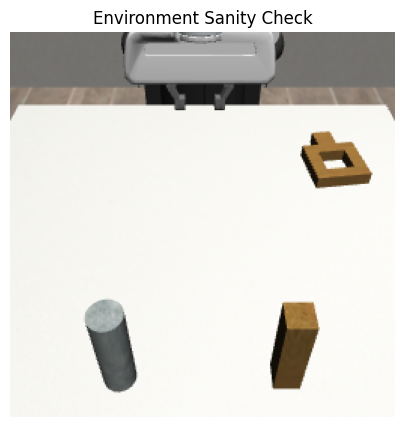

3. Render 成功 | 你应该能看到一张包含机械臂和红方块的图片。


In [7]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 测试环境重置 (Reset)
obs = wrapper.reset()
print(f"1. Reset 成功 | 初始观测维度: {obs.shape}")

# 2. 测试环境交互 (Step) - 执行一个随机动作
# 我们用全 0 动作或者随机动作测试
action = np.zeros(wrapper.action_space.shape) 
next_obs, reward, done, info = wrapper.step(action)
print(f"2. Step 成功  | Step后观测维度: {next_obs.shape}, Reward: {reward}")

# 3. 测试图像渲染 (Render) - 这是最容易报错的一步 (例如缺少 OpenGL 库)
try:
    img = wrapper.render()
    
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title("Environment Sanity Check")
    plt.axis('off')
    plt.show()
    
    print("3. Render 成功 | 你应该能看到一张包含机械臂和红方块的图片。")
    
except Exception as e:
    print("\n[错误] 渲染失败！")
    print(f"错误信息: {e}")
    print("提示: 如果是在无头服务器(Headless Server)上，可能需要配置 EGL 或使用 xvfb-run。")

### Dataset


In [8]:
from Common.myrotation_transformer_final import RotationTransformer

rotation_transformer = RotationTransformer('rotation_6d', 'axis_angle')

action_dim = 10 

print(f"已初始化 RotationTransformer，Action Dim 设置为: {action_dim}")

已初始化 RotationTransformer，Action Dim 设置为: 10


In [9]:
class MinMaxNormalizer:
    def __init__(self, data=None, min_val=None, max_val=None):
        """
        可以传入 data 自动计算 min/max，也可以直接传入已知的 min/max
        """
        if data is not None:
            # 假设 data 是 (N, Dim)
            self.min_val = np.min(data, axis=0)
            self.max_val = np.max(data, axis=0)
        else:
            self.min_val = np.array(min_val)
            self.max_val = np.array(max_val)
            
        # 防止除以零（如果某维度没有变化）
        self.scale = self.max_val - self.min_val
        self.scale[self.scale == 0] = 1.0 

    def normalize(self, x):
        # 归一化到 [0, 1]
        norm = (x - self.min_val) / self.scale
        # 映射到 [-1, 1]
        return norm * 2 - 1

    def denormalize(self, x):
        # 从 [-1, 1] 映射回 [0, 1]
        denorm = (x + 1) / 2
        # 还原到原始范围
        return denorm * self.scale + self.min_val

In [10]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import h5py
from tqdm import tqdm

# 假设 RotationTransformer 和 MinMaxNormalizer 已经在上面定义好了
# from your_utils import RotationTransformer, MinMaxNormalizer 

class RobomimicDataset(Dataset):
    def __init__(self, 
                 dataset_path, 
                 obs_keys, 
                 pred_horizon, 
                 obs_horizon, 
                 action_horizon):
        
        # 参数记录
        self.pred_horizon = pred_horizon
        self.obs_horizon = obs_horizon
        self.action_horizon = action_horizon
        self.obs_keys = obs_keys
        
        # --- 新增：初始化旋转变换器 ---
        # 用于将 Axis-Angle (3) 转为 Rotation 6D (6)
        self.rotation_transformer = RotationTransformer(
            from_rep='axis_angle', to_rep='rotation_6d')

        # 1. 读取数据到内存
        print(f"正在加载数据集: {dataset_path}")
        with h5py.File(dataset_path, 'r') as f:
            demos = f['data']
            self.all_obs = []
            self.all_actions = [] # 这里将存储转换后的 10维动作
            
            for key in tqdm(demos.keys(), desc="Loading"):
                demo = demos[key]
                
                # --- 处理 Observation (保持不变) ---
                obs_list = []
                for k in self.obs_keys:
                    obs_data = demo['obs'][k][:] 
                    obs_list.append(obs_data)
                obs_seq = np.concatenate(obs_list, axis=-1)
                self.all_obs.append(obs_seq)
                
                # --- 修改重点：处理 Action (7维 -> 10维) ---
                raw_actions = demo['actions'][:].astype(np.float32) # (T, 7)
                
                # 1. 拆分动作
                pos = raw_actions[:, :3]     # (T, 3)
                rot = raw_actions[:, 3:6]    # (T, 3) Axis-Angle
                gripper = raw_actions[:, 6:] # (T, 1)
                
                # 2. 旋转变换 (Axis-Angle -> Rotation 6D)
                # Transformer 接收 Tensor，返回 Tensor，需转回 Numpy
                rot_tensor = torch.from_numpy(rot)
                rot_6d_tensor = self.rotation_transformer.forward(rot_tensor)
                rot_6d = rot_6d_tensor.numpy() # (T, 6)
                
                # 3. 拼接成绝对位置控制所需的格式 (T, 10)
                # 3 pos + 6 rot + 1 gripper = 10 dim
                new_actions = np.concatenate([pos, rot_6d, gripper], axis=-1)
                
                self.all_actions.append(new_actions)

        # 2. 计算统计数据并初始化归一化器
        # 把所有数据拼在一起
        all_obs_concat = np.concatenate(self.all_obs, axis=0)
        all_action_concat = np.concatenate(self.all_actions, axis=0)
        
        # --- 修改重点：使用类 MinMaxNormalizer ---
        # 此时 all_action_concat 已经是 10维的数据了
        self.obs_normalizer = MinMaxNormalizer(data=all_obs_concat)
        self.action_normalizer = MinMaxNormalizer(data=all_action_concat)
        
        # 打印一下验证维度
        print(f"原始 Action 维度: 7, 转换后 Action 维度: {all_action_concat.shape[-1]}")
        
        # 3. 预处理：归一化所有数据并建立索引
        self.normalized_obs = []
        self.normalized_actions = []
        self.indices = []
        
        for i in range(len(self.all_obs)):
            # --- 修改重点：调用实例方法进行归一化 ---
            n_obs = self.obs_normalizer.normalize(self.all_obs[i])
            n_action = self.action_normalizer.normalize(self.all_actions[i])
            
            self.normalized_obs.append(n_obs)
            self.normalized_actions.append(n_action)
            
            # 建立索引 (逻辑不变)
            episode_len = n_obs.shape[0]
            # 为了保证剩下的长度够 pred_horizon，需要减去它
            for start_ts in range(episode_len - self.pred_horizon):
                self.indices.append((i, start_ts))
                
        print(f"加载完成! 样本数量: {len(self.indices)}")

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        episode_idx, start_ts = self.indices[idx]
        
        n_obs = self.normalized_obs[episode_idx]
        n_action = self.normalized_actions[episode_idx]
        
        # 1. 取 Observation
        # 注意：这里如果 obs_horizon > 1，需要处理边界情况(padding)，
        # 但为简化起见，假设 start_ts + obs_horizon 不会越界(因为上面 range 只减了 pred_horizon)
        # 实际严谨代码通常会在上面 range 减去 max(obs_horizon, pred_horizon)
        obs_seq = n_obs[start_ts : start_ts + self.obs_horizon, :]
        
        # 2. 取 Action
        action_seq = n_action[start_ts : start_ts + self.pred_horizon, :]
        
        data = {
            'obs': torch.from_numpy(obs_seq).float(),      # shape: (obs_horizon, obs_dim)
            'action': torch.from_numpy(action_seq).float() # shape: (pred_horizon, 10)
        }
        return data

    # --- 新增：提供一个反归一化+逆变换的辅助函数，供推理时使用 ---
    def get_unnormalized_action(self, n_action_pred):
        """
        推理时使用：
        输入: 模型预测的归一化动作 (B, 10) Tensor or Numpy
        输出: 环境可执行的动作 (B, 7) Numpy
        """
        is_tensor = isinstance(n_action_pred, torch.Tensor)
        if is_tensor:
            n_action_pred = n_action_pred.detach().cpu().numpy()
            
        # 1. 反归一化 (10D -> 10D)
        action_10d = self.action_normalizer.denormalize(n_action_pred)
        
        # 2. 拆解
        pos = action_10d[..., :3]
        rot_6d = action_10d[..., 3:9]
        gripper = action_10d[..., 9:]
        
        # 3. 逆旋转变换 (6D -> 3D Axis-Angle)
        rot_6d_tensor = torch.from_numpy(rot_6d)
        rot_axis = self.rotation_transformer.inverse(rot_6d_tensor).numpy()
        
        # 4. 拼接 (10D -> 7D)
        action_7d = np.concatenate([pos, rot_axis, gripper], axis=-1)
        return action_7d

In [11]:
# 配置参数 (这些是 Diffusion Policy 的标准参数)
pred_horizon = 16    # 预测未来 16 步
obs_horizon = 2      # 看过去 2 步
action_horizon = 8   # (这一步在 dataset 里用不到，但在推理时有用)

# 1. 实例化 Dataset
dataset = RobomimicDataset(
    dataset_path=dataset_path, # 确保这个变量是你之前定义的路径
    obs_keys=[
        'object', 
        'robot0_eef_pos', 
        'robot0_eef_quat', 
        'robot0_gripper_qpos'
    ],
    pred_horizon=pred_horizon,
    obs_horizon=obs_horizon,
    action_horizon=action_horizon
)

# 2. 实例化 DataLoader
dataloader = DataLoader(
    dataset, 
    batch_size=64, 
    shuffle=True, 
    num_workers=3, # 本地调试设为 0 比较稳妥，避免多进程报错
    pin_memory=True
)

# 3. 验证一下输出形状
batch = next(iter(dataloader))
print("\n--- 数据形状检查 ---")
print(f"Obs Batch:    {batch['obs'].shape}")
print(f"Action Batch: {batch['action'].shape}")
print(f"Observation Space: {wrapper.observation_space}")

正在加载数据集: /home/users/oscar/streaming-flow-policy/data/square/ph/low_dim_abs.hdf5


Loading: 100%|██████████| 200/200 [00:00<00:00, 475.81it/s]

原始 Action 维度: 7, 转换后 Action 维度: 10
加载完成! 样本数量: 26954



--- 数据形状检查 ---
Obs Batch:    torch.Size([64, 2, 23])
Action Batch: torch.Size([64, 16, 10])
Observation Space: Box(-1.0, 1.0, (23,), float64)


### Model

In [12]:
class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim, scale = 1):
        super().__init__()
        self.dim = dim
        self.scale = scale # added - SFP

    def forward(self, x):
        x = x * self.scale
        device = x.device
        half_dim = self.dim // 2
        emb = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)
        emb = x[:, None] * emb[None, :]
        emb = torch.cat((emb.sin(), emb.cos()), dim=-1)
        return emb

class ConvDownsample1d(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.conv = nn.Conv1d(dim, dim, 3, 2, 1)

    def forward(self, x):
        return self.conv(x)

class ConvUpsample1d(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.conv = nn.ConvTranspose1d(dim, dim, 4, 2, 1)

    def forward(self, x):
        return self.conv(x)

class LinearDownsample1d(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.linear = nn.Linear(dim, dim)

    def forward(self, x: Tensor):
        # Reshape input to (batch_size, -1) for fully connected layer
        batch_size, channels, seq_len = x.size()
        x = x.view(batch_size, -1)  # flatten spatial dimensions
        x = self.linear(x)
        x = x.view(batch_size, channels, seq_len)  # reshape back to original dimensions
        return x

class LinearUpsample1d(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.linear = nn.Linear(dim, dim)

    def forward(self, x: Tensor):
        # Reshape input to (batch_size, -1) for fully connected layer
        batch_size, channels, seq_len = x.size()
        x = x.view(batch_size, -1)  # flatten spatial dimensions
        x = self.linear(x)
        x = x.view(batch_size, channels, seq_len)  # reshape back to original dimensions
        return x

class Conv1dBlock(nn.Module):
    '''
        Conv1d --> GroupNorm --> Mish
    '''

    def __init__(self, inp_channels, out_channels, kernel_size, n_groups=8):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv1d(inp_channels, out_channels, kernel_size, padding=kernel_size // 2),
            nn.GroupNorm(n_groups, out_channels),
            nn.Mish(),
        )

    def forward(self, x):
        return self.block(x)

class ConditionalResidualBlock1D(nn.Module):
    def __init__(self,
            in_channels,
            out_channels,
            cond_dim,
            kernel_size=3,
            n_groups=8,
                 ):
        super().__init__()

        self.blocks = nn.ModuleList([
            Conv1dBlock(in_channels, out_channels, kernel_size, n_groups=n_groups),
            Conv1dBlock(out_channels, out_channels, kernel_size, n_groups=n_groups),
        ])

        # FiLM modulation https://arxiv.org/abs/1709.07871
        # predicts per-channel scale and bias
        cond_channels = out_channels * 2
        self.out_channels = out_channels
        self.cond_encoder = nn.Sequential(
            nn.Mish(),
            nn.Linear(cond_dim, cond_channels),
            nn.Unflatten(-1, (-1, 1))
        )

        # Ensure dimensions compatible
        self.residual_conv = nn.Conv1d(in_channels, out_channels, 1) \
            if in_channels != out_channels else nn.Identity()

    def forward(self, x, cond):
        '''
            x : [ batch_size x in_channels x horizon ]
            cond : [ batch_size x cond_dim]

            returns:
            out : [ batch_size x out_channels x horizon ]
        '''
        out = self.blocks[0](x)
        embed = self.cond_encoder(cond)

        embed = embed.reshape(
            embed.shape[0], 2, self.out_channels, 1)
        scale = embed[:,0,...]
        bias = embed[:,1,...]
        out = scale * out + bias

        out = self.blocks[1](out)
        out = out + self.residual_conv(x)
        return out

class ConditionalUnet1D (nn.Module):
    def __init__(self,
        input_dim,
        global_cond_dim,
        updownsample_type: Literal['Conv', 'Linear'],  # added for SFP
        sin_embedding_scale,  # added for SFP
        diffusion_step_embed_dim=256,
        down_dims=[256,512,1024],
        kernel_size=5,
        n_groups=8,
        ):
        """
        input_dim: Dim of actions.
        global_cond_dim: Dim of global conditioning applied with FiLM
          in addition to diffusion step embedding. This is usually obs_horizon * obs_dim
        diffusion_step_embed_dim: Size of positional encoding for diffusion iteration k
        down_dims: Channel size for each UNet level.
          The length of this array determines numebr of levels.
        kernel_size: Conv kernel size
        n_groups: Number of groups for GroupNorm
        """

        super().__init__()
        all_dims = [input_dim] + list(down_dims)
        start_dim = down_dims[0]

        dsed = diffusion_step_embed_dim
        diffusion_step_encoder = nn.Sequential(
            SinusoidalPosEmb(dsed, scale = sin_embedding_scale), # added - SFP
            nn.Linear(dsed, dsed * 4),
            nn.Mish(),
            nn.Linear(dsed * 4, dsed),
        )
        cond_dim = dsed + global_cond_dim

        in_out = list(zip(all_dims[:-1], all_dims[1:]))
        mid_dim = all_dims[-1]
        self.mid_modules = nn.ModuleList([
            ConditionalResidualBlock1D(
                mid_dim, mid_dim, cond_dim=cond_dim,
                kernel_size=kernel_size, n_groups=n_groups
            ),
            ConditionalResidualBlock1D(
                mid_dim, mid_dim, cond_dim=cond_dim,
                kernel_size=kernel_size, n_groups=n_groups
            ),
        ])

        down_modules = nn.ModuleList([])
        for ind, (dim_in, dim_out) in enumerate(in_out):
            is_last = ind >= (len(in_out) - 1)
            if updownsample_type == 'Linear':  # added for SFP
                downsample_layer = LinearDownsample1d(dim_out) if not is_last else nn.Identity() #added
            elif updownsample_type == 'Conv':
                downsample_layer = ConvDownsample1d(dim_out) if not is_last else nn.Identity()
            else:
                raise ValueError(f"Unsupported updownsample_type: {updownsample_type}")
            down_modules.append(nn.ModuleList([
                ConditionalResidualBlock1D(
                    dim_in, dim_out, cond_dim=cond_dim,
                    kernel_size=kernel_size, n_groups=n_groups),
                ConditionalResidualBlock1D(
                    dim_out, dim_out, cond_dim=cond_dim,
                    kernel_size=kernel_size, n_groups=n_groups),
                downsample_layer,
            ]))

        up_modules = nn.ModuleList([])
        for ind, (dim_in, dim_out) in enumerate(reversed(in_out[1:])):
            is_last = ind >= (len(in_out) - 1)
            if updownsample_type == 'Linear':  # added for SFP
                upsample_layer = LinearUpsample1d(dim_in) if not is_last  else nn.Identity()
            elif updownsample_type == 'Conv':
                upsample_layer = ConvUpsample1d(dim_in) if not is_last  else nn.Identity()
            else:
                raise ValueError(f"Unsupported updownsample_type: {updownsample_type}")
            up_modules.append(nn.ModuleList([
                ConditionalResidualBlock1D(
                    dim_out*2, dim_in, cond_dim=cond_dim,
                    kernel_size=kernel_size, n_groups=n_groups),
                ConditionalResidualBlock1D(
                    dim_in, dim_in, cond_dim=cond_dim,
                    kernel_size=kernel_size, n_groups=n_groups),
                upsample_layer,
            ]))

        final_conv = nn.Sequential(
            Conv1dBlock(start_dim, start_dim, kernel_size=kernel_size),
            nn.Conv1d(start_dim, input_dim, 1),
        )

        self.diffusion_step_encoder = diffusion_step_encoder
        self.up_modules = up_modules
        self.down_modules = down_modules
        self.final_conv = final_conv

        print("Number of parameters: {:e}".format(
            sum(p.numel() for p in self.parameters()))
        )

    def forward(self,
            sample: Tensor,
            timestep: Union[Tensor, float, int],
            global_cond=None,
        ) -> Tensor:
        """
        x: (B,T,input_dim)
        timestep: (B,) or int, diffusion step
        global_cond: (B,global_cond_dim)
        output: (B,T,input_dim)
        """
        # (B,T,C)
        sample = sample.moveaxis(-1,-2)
        # (B,C,T)

        # 1. time
        timesteps = timestep
        if not torch.is_tensor(timesteps):
            # TODO: this requires sync between CPU and GPU. So try to pass timesteps as tensors if you can
            timesteps = torch.tensor([timesteps], dtype=torch.long, device=sample.device)
        elif torch.is_tensor(timesteps) and len(timesteps.shape) == 0:
            timesteps = timesteps[None].to(sample.device)
        # broadcast to batch dimension in a way that's compatible with ONNX/Core ML
        timesteps = timesteps.expand(sample.shape[0])

        global_feature = self.diffusion_step_encoder(timesteps)

        if global_cond is not None:
            global_feature = torch.cat([
                global_feature, global_cond
            ], axis=-1)

        x = sample
        h = []
        for idx, (resnet, resnet2, downsample) in enumerate(self.down_modules):
            x = resnet(x, global_feature)
            x = resnet2(x, global_feature)
            h.append(x)
            x = downsample(x)

        for mid_module in self.mid_modules:
            x = mid_module(x, global_feature)

        for idx, (resnet, resnet2, upsample) in enumerate(self.up_modules):
            x = torch.cat((x, h.pop()), dim=1)
            x = resnet(x, global_feature)
            x = resnet2(x, global_feature)
            x = upsample(x)

        x = self.final_conv(x)

        # (B,C,T)
        x = x.moveaxis(-1,-2)
        # (B,T,C)
        return x

### DP

In [13]:
# 基于之前的 Lift 任务设置
action_dim = 10      # 动作维度
obs_dim = 23         # 观测特征维度
obs_horizon = 2      # 观测历史长度

# 实例化模型
dp_noise_pred_net = ConditionalUnet1D(
    input_dim=action_dim,
    global_cond_dim=obs_dim * obs_horizon,
    updownsample_type='Conv',
    sin_embedding_scale=1,
)

print("模型构建成功！")

num_diffusion_iters = 100
noise_scheduler = DDPMScheduler(
    num_train_timesteps=num_diffusion_iters,
    # the choise of beta schedule has big impact on performance
    # we found squared cosine works the best
    beta_schedule='squaredcos_cap_v2',
    # clip output to [-1,1] to improve stability
    clip_sample=True,
    # our network predicts noise (instead of denoised action)
    prediction_type='epsilon'
)

# device transfer
device = torch.device('cuda')
dp_noise_pred_net = dp_noise_pred_net.to(device)

Number of parameters: 6.588366e+07
模型构建成功！


In [ ]:
num_epochs = 100

# Exponential Moving Average
# accelerates training and improves stability
# holds a copy of the model weights
ema_dp = EMAModel(
    parameters=dp_noise_pred_net.parameters(),
    power=0.75)

# Standard ADAM optimizer
# Note that EMA parametesr are not optimized
optimizer = torch.optim.AdamW(
    params=dp_noise_pred_net.parameters(),
    lr=1e-4, weight_decay=1e-6)

# Cosine LR schedule with linear warmup
lr_scheduler = get_scheduler(
    name='cosine',
    optimizer=optimizer,
    num_warmup_steps=500,
    num_training_steps=len(dataset) * num_epochs
)

with tqdm(range(num_epochs), desc='Epoch') as tglobal:
    # epoch loop
    for epoch_idx in tglobal:
        epoch_loss = list()
        # batch loop
        with tqdm(dataloader, desc='Batch', leave=False) as tepoch:
            for nbatch in tepoch:
                # Note that the data is normalized in the dataset.
                # Device transfer
                nobs = nbatch['obs'].to(device)  # (B, To, O)
                naction = nbatch['action'].to(device)  # (B, Tp, A)
                B = nobs.shape[0]

                # Observation as FiLM conditioning
                obs_cond = nobs.flatten(start_dim=1)  # (B, To*O)

                # Sample noise to add to actions
                noise = torch.randn(naction.shape, device=device)  # (B, Tp, A)

                # sample a diffusion iteration for each data point
                timesteps = torch.randint(
                    0, noise_scheduler.config.num_train_timesteps,
                    (B,), device=device
                ).long()  # (B,)

                # Forward diffusion process: Add noise to the clean images
                # according to the noise magnitude at each diffusion iteration.
                noisy_actions = noise_scheduler.add_noise(
                    naction, noise, timesteps)  # (B, Tp, A)

                # Predict the noise residual.
                noise_pred = dp_noise_pred_net(
                    noisy_actions, timesteps, global_cond=obs_cond)

                # L2 loss
                loss = nn.functional.mse_loss(noise_pred, noise)

                # optimize
                loss.backward()
                optimizer.step()
                optimizer.zero_grad()
                # step lr scheduler every batch
                # this is different from standard pytorch behavior
                lr_scheduler.step()

                # update Exponential Moving Average of the model weights
                ema_dp.step(dp_noise_pred_net.parameters())

                # logging
                loss_cpu = loss.item()
                epoch_loss.append(loss_cpu)
                tepoch.set_postfix(loss=loss_cpu)
        tglobal.set_postfix(loss=np.mean(epoch_loss))

# Weights of the EMA model
# is used for inference
ema_noise_pred_net_dp = dp_noise_pred_net
ema_dp.copy_to(ema_noise_pred_net_dp.parameters())

In [ ]:
import collections
import numpy as np
import torch
from tqdm.auto import tqdm
import imageio  # 用于保存 GIF

# 1. 准备参数
# 确保模型处于推理模式
dp_noise_pred_net.eval()
dp_noise_pred_net.to(device)

# 设置参数 (必须与训练时一致)
max_steps = 400  # 最大运行步数
obs_horizon = 2
pred_horizon = 16
action_horizon = 8
num_diffusion_iters = 100 

# 2. 重置环境
obs = wrapper.reset()

# 初始化观测队列
obs_deque = collections.deque([obs] * obs_horizon, maxlen=obs_horizon)

# 用于保存可视化图像和奖励
imgs = [wrapper.render()]
rewards = list()
done = False
step_idx = 0

print("开始推理 (Inference)...")

# 3. 推理循环
with tqdm(total=max_steps, desc="Eval Robomimic") as pbar:
    while not done:
        # --- A. 数据准备 ---
        # 拼接最近 obs_horizon 步的观测数据
        obs_seq = np.stack(obs_deque) # (2, 19)
        
        # [修改点 1]: 使用 dataset 里的实例归一化器
        nobs = dataset.obs_normalizer.normalize(obs_seq)
        
        # 转 Tensor 并增加 Batch 维度
        nobs = torch.from_numpy(nobs).to(device, dtype=torch.float32)
        
        # 构造 Global Conditioning: (1, obs_horizon * 19)
        obs_cond = nobs.unsqueeze(0).flatten(start_dim=1)

        # --- B. 生成动作 (反向扩散) ---
        with torch.no_grad():
            # [修改点 2]: 初始化纯高斯噪音，维度改为 10 (3pos + 6rot + 1gripper)
            # 原始代码是 7，现在必须是 10
            na_traj = torch.randn(
                (1, pred_horizon, 10), 
                device=device
            )

            # 设置调度器时间步
            noise_scheduler.set_timesteps(num_diffusion_iters)

            # 逐步去噪
            for k in noise_scheduler.timesteps:
                # 预测噪音
                noise_pred = dp_noise_pred_net(
                    sample=na_traj,
                    timestep=k,
                    global_cond=obs_cond
                )

                # 移除噪音
                na_traj = noise_scheduler.step(
                    model_output=noise_pred,
                    timestep=k,
                    sample=na_traj,
                ).prev_sample

        # --- C. 后处理 ---
        # 转回 CPU numpy: (1, 16, 10) -> (16, 10)
        na_traj = na_traj.detach().to('cpu').numpy()[0]
        
        # [修改点 3]: 调用 dataset 的辅助函数进行 反归一化 + 逆旋转变换
        # 输入 (16, 10) -> 输出 (16, 7)
        # 这个函数内部会自动处理: 10D反归一化 -> 6D旋转转AxisAngle -> 拼接回7D
        action_pred = dataset.get_unnormalized_action(na_traj)

        # --- D. 动作切片与执行 (逻辑不变) ---
        start = obs_horizon - 1
        end = start + action_horizon
        
        # 取出未来 action_horizon 步的动作
        action_chunk = action_pred[start:end, :] 
        
        # --- E. 执行动作序列 ---
        for action in action_chunk:
            # 环境交互 (此时 action 已经是环境能懂的 7维 格式了)
            obs, reward, done, info = wrapper.step(action)
            
            # 更新历史观测
            obs_deque.append(obs)
            
            # 记录数据
            rewards.append(reward)
            imgs.append(wrapper.render())
            
            # 进度更新
            step_idx += 1
            pbar.update(1)
            pbar.set_postfix(reward=reward)
            
            if step_idx >= max_steps:
                done = True
            if done:
                break

print(f"推理结束! 总得分: {max(rewards)}")

# 4. 保存结果为 GIF
save_path = "eval_robomimic_abs.gif"
print(f"正在保存视频到: {save_path} ...")
imageio.mimsave(save_path, imgs, fps=10)
print("保存完成！")

### SSIP

In [17]:
# =========================================================
# 1. 辅助函数: Gamma 调度器 (参考 model.py)
# =========================================================
EPS = 1e-6

def gamma_t_si(t):
    # 使用简单的抛物线/气泡形状，在 t=0 和 t=1 时为 0，中间膨胀
    # 这里的系数 0.1 控制 "SI 气泡" 的大小，相对于 SFP 的管状噪声
    return 0.1 * torch.sqrt(t * (1.0 - t) + EPS)

def d_gamma_dt_si(t):
    # gamma(t) 对 t 的导数
    return 0.1 * (1.0 - 2.0 * t) / (2.0 * torch.sqrt(t * (1.0 - t) + EPS))

# =========================================================
# 2. 初始化模型 (VelocityNet 和 DenoiserNet)
# =========================================================
# SFP 参数


pred_horizon = 16
action_dim = 10       # 动作维度
obs_dim = 23         # 观测特征维度
obs_horizon = 2      # 观测历史长度


# 我们需要两个网络：
# 1. si_velocity_net: 预测确定性速度场 (v)
# 2. si_denoiser_net: 预测噪声场 (eta/score)

si_velocity_net = ConditionalUnet1D(
    input_dim=action_dim,
    global_cond_dim=obs_dim*obs_horizon,
    updownsample_type='Linear',
    sin_embedding_scale=100,
).to(device)

si_denoiser_net = ConditionalUnet1D(
    input_dim=action_dim,
    global_cond_dim=obs_dim*obs_horizon,
    updownsample_type='Linear',
    sin_embedding_scale=100,
).to(device)

print("Models initialized for Streaming SI Policy.")

# =========================================================
# 3. 优化器设置
# =========================================================
optimizer_si = torch.optim.AdamW([
    {'params': si_velocity_net.parameters()},
    {'params': si_denoiser_net.parameters()}
], lr=1e-4, weight_decay=1e-6)

# EMA (Exponential Moving Average) for better inference stability
ema_si_v = EMAModel(parameters=si_velocity_net.parameters(), power=0.75)
ema_si_eta = EMAModel(parameters=si_denoiser_net.parameters(), power=0.75)

num_epochs_si = 2000
lr_scheduler_si = get_scheduler(
    name='cosine',
    optimizer=optimizer_si,
    num_warmup_steps=500,
    num_training_steps=len(dataloader) * num_epochs_si
)

Number of parameters: 6.424526e+07
Number of parameters: 6.424526e+07
Models initialized for Streaming SI Policy.


In [18]:
def LinearlyInterpolateTrajectory(ξ, t):
    """
    Vectorized computation of positions and velocities if each trajectory
    (from a batch of trajectories) at given times for each trajectory, using
    linear interpolation.

    ξ (Tensor, dtype=float, shape=(B, T, A)): batch of action trajectories.
    t (Tensor, dtype=float, shape=(B,)): batch of times in [0, 1].

    Returns:
        ξt   (Tensor, shape=(B, A)): positions at time t
        dξdt (Tensor, shape=(B, A)): velocities at time t
    """
    B, T, A = ξ.shape

    # Compute the lower and upper limits of the bins that the time-points lie in.
    scaled_t = t * (T - 1)  # (B,) lies in [0, T-1]
    l = scaled_t.floor().long().clamp(0, T - 2)  # (B,) lower bin limits
    u = (l + 1).clamp(0, T - 1)  # (B,) upper bin limits
    λ = scaled_t - l.float()  # fractional part, lies in [0, 1]

    # Query the values of the upper and lower bin limits.
    batch_idx = torch.arange(B, device=ξ.device)  # (B,)
    ξl = ξ[batch_idx, l, :]  # (B, A)
    ξu = ξ[batch_idx, u, :]  # (B, A)

    # Linearly interpolate between bin limits to get position.
    λ = λ.unsqueeze(-1)  # (B, 1)
    ξt = ξl + λ * (ξu - ξl)  # (B, A)

    # Compute velocity as first-order hold.
    # Note that the time interval between two bins is Δt = 1 / (T-1).
    dξdt = (ξu - ξl) * (T - 1)  # (B, A)

    return ξt, dξdt  # (B, A) and (B, A)

def SampleCFMInputsAndTargets(ξt, dξdt, t, k, σ0):
    """
    Sample inputs and targets for the conditional flow matching loss (CFM)
    given positions and velocities at time t.

    This functions performs the following sampling (Eq. 2 and 3 of the paper):
        a ~ N(ξ(t), σ₀² exp(-2kt))  # (Eq. 3 in the paper)
        v = -k (a - ξ(t)) + dξdt(t)  # (Eq. 2 in the paper)

    Args:
        ξt (Tensor, shape=(B, A)): positions at time t.
        dξdt (Tensor, shape=(B, A)): velocities at time t.
        t (Tensor, shape=(B,)): times in [0, 1].
        k (float): Stabilizing gains of the conditional flow.
        σ0 (float): initial standard deviation of the noise added to the action.

    Returns:
        a (Tensor, shape=(B, A)): noised actions at time t
        v (Tensor, shape=(B, A)): noised action velocity targets at time t
    """
    # error = σ0 * torch.exp(-k*t).unsqueeze(1) * torch.randn_like(xt)
    t = t.unsqueeze(-1)  # (B, 1)
    sampled_error = σ0 * torch.exp(-k * t) * torch.randn_like(ξt)  # (B, A)
    a = ξt + sampled_error  # (B, A) ⟸ Eq. 3 in the paper
    v = -k * sampled_error + dξdt  # (B, A) ⟸ Eq. 2 in the paper

    return a, v  # (B, A) and (B, A)

In [19]:
# =========================================================
# 训练循环: Conditional Streaming SI Policy
# =========================================================
sigma0 = 0.4  # SFP 初始管状半径
k = 10.0      # SFP 稳定系数


print("Starting training for Streaming SI Policy...")

with tqdm(range(num_epochs_si), desc='Epoch') as tglobal:
    for epoch_idx in tglobal:
        epoch_loss = []
        # 用于记录每个 epoch 的平均分项 loss
        epoch_v_loss = []
        epoch_eta_loss = []
        
        with tqdm(dataloader, desc='Batch', leave=False) as tepoch:
            for nbatch in tepoch:
                # 1. 数据准备
                nobs = nbatch['obs'].to(device)
                naction = nbatch['action'].to(device)
                
                # 提取当前及未来的动作片段
                ξ = naction[:, obs_horizon-1:, :] 
                B = ξ.shape[0]
                
                # 随机采样时间 t ~ U[0, 1]
                t = torch.rand(B, device=device)
                
                # 2. 计算 Ground Truth 位置和速度 (Linearly Interpolate)
                ξt, dξdt = LinearlyInterpolateTrajectory(ξ, t)
                
                # 3. 构建 Flow Matching (FP) 基础目标 (管状分布)
                # a_t_fp = ξ(t) + σ(t) * ε1
                # 这里的 σ(t) = σ0 * exp(-kt)
                t_expanded = t.view(B, 1)
                sigma_t_fp = sigma0 * torch.exp(-k * t_expanded)
                noise_fp = torch.randn_like(ξt)
                a_t_fp = ξt + sigma_t_fp * noise_fp
                
                # 计算 Velocity Target (指向轨迹的向量场)
                # v_target = dξ/dt - k * (a_t_fp - ξ(t))
                # 注意：这个速度是定义在 a_t_fp 上的
                v_target = dξdt - k * (a_t_fp - ξt)
                
                # 4. 构建 Stochastic Interpolant (SI) 扰动
                # x_t = a_t_fp + γ(t) * z
                # 我们在 SFP 的管子外面再套一层 SI 的气泡
                gamma = gamma_t_si(t_expanded)
                z_noise_si = torch.randn_like(ξt)
                x_t_in_s = a_t_fp + gamma * z_noise_si
                
                # 5. 网络前向传播
                # 输入需要 reshape 成 (B, 1, A) 以适应 UNet 接口
                net_input = x_t_in_s.unsqueeze(1)
                global_cond = nobs.flatten(start_dim=1)
                
                # 预测速度
                v_pred = si_velocity_net(sample=net_input, timestep=t, global_cond=global_cond)
                v_pred = v_pred.squeeze(1)
                
                # 预测噪声 (Score 相关的量)
                eta_pred = si_denoiser_net(sample=net_input, timestep=t, global_cond=global_cond)
                eta_pred = eta_pred.squeeze(1)
                
                # 6. 计算 Loss
                loss_v = nn.functional.mse_loss(v_pred, v_target)
                loss_eta = nn.functional.mse_loss(eta_pred, z_noise_si)
                
                loss = loss_v + loss_eta
                
                # 7. 反向传播
                loss.backward()
                optimizer_si.step()
                optimizer_si.zero_grad()
                lr_scheduler_si.step()
                
                # 更新 EMA
                ema_si_v.step(si_velocity_net.parameters())
                ema_si_eta.step(si_denoiser_net.parameters())
                
                # 记录数据
                loss_val = loss.item()
                v_loss_val = loss_v.item()
                eta_loss_val = loss_eta.item()
                
                epoch_loss.append(loss_val)
                epoch_v_loss.append(v_loss_val)
                epoch_eta_loss.append(eta_loss_val)
                
                # [修改点] 这里增加了 s_loss (score loss) 的显示
                tepoch.set_postfix(loss=loss_val, v_loss=v_loss_val, s_loss=eta_loss_val)
                
        # [修改点] Epoch 结束时也可以看平均的分项 Loss
        tglobal.set_postfix(
            loss=np.mean(epoch_loss), 
            v_loss=np.mean(epoch_v_loss), 
            s_loss=np.mean(epoch_eta_loss)
        )

        if (epoch_idx + 1) % 250 == 0:
            ckpt_path_epoch = f"models/square_state_{epoch_idx+1}ep_si_abs.ckpt"
            torch.save({
                'velocity_net': si_velocity_net.state_dict(),
                'denoiser_net': si_denoiser_net.state_dict()
            }, ckpt_path_epoch)
            print(f" Saved checkpoint to {ckpt_path_epoch}")

# 保存模型
ckpt_path_si = "models/square_state_2000ep_si_abs.ckpt"
torch.save({
    'velocity_net': si_velocity_net.state_dict(),
    'denoiser_net': si_denoiser_net.state_dict()
}, ckpt_path_si)
print(f"Saved Streaming SI model to {ckpt_path_si}")

# 准备推理用的 EMA 模型
ema_si_velocity_net = si_velocity_net
ema_si_denoiser_net = si_denoiser_net
ema_si_v.copy_to(ema_si_velocity_net.parameters())
ema_si_eta.copy_to(ema_si_denoiser_net.parameters())

Starting training for Streaming SI Policy...


Epoch:   0%|          | 9/2000 [04:33<16:46:59, 30.35s/it, loss=1.45, s_loss=0.747, v_loss=0.706]


KeyboardInterrupt: 

In [ ]:
# =========================================================
# 加载预训练的 Streaming SI Policy 模型 (跳过训练)
# =========================================================

load_pretrained = True
ckpt_path_si = "models/can_state_1200_ep_si_abs.ckpt"

# 检查文件是否存在
if load_pretrained and os.path.isfile(ckpt_path_si):
    print(f"Found pretrained checkpoint: {ckpt_path_si}")
    checkpoint = torch.load(ckpt_path_si, map_location=device)

    # 1. 加载权重到基础网络
    si_velocity_net.load_state_dict(checkpoint['velocity_net'])
    si_denoiser_net.load_state_dict(checkpoint['denoiser_net'])

    # 2. 设置推理用的模型
    # 在跳过训练的情况下，我们将直接使用加载的权重作为推理模型
    # (模拟 EMA 模型及其接口)
    ema_si_velocity_net = si_velocity_net
    ema_si_denoiser_net = si_denoiser_net

    print('Pretrained weights loaded for Streaming SI Policy. Ready for inference!')

else:
    print(f"Checkpoint {ckpt_path_si} not found. Please run the training cell below.")
    # 如果需要，这里可以初始化 EMA 模型容器，以便后续训练使用
    # ema_si_velocity_net = ... (通常在训练循环中通过 EMAModel 初始化)

Found pretrained checkpoint: models/lift_state_1200_ep_si_abs.ckpt
Pretrained weights loaded for Streaming SI Policy. Ready for inference!


In [19]:
import collections
import numpy as np
import torch
import math
import imageio
from tqdm.auto import tqdm
from scipy.spatial.transform import Rotation as R

# =========================================================
# 辅助函数: 计算 Drift (适配 10维 Action)
# =========================================================
def get_drift(x, t, global_cond, sigma_infer, eps=1e-6):
    """
    计算修正后的漂移项 b(x, t)
    x: (B, 1, 10)
    """
    if t.ndim == 0: t = t.unsqueeze(0)
    
    # 预测 v 和 eta
    v_pred = ema_si_velocity_net(sample=x, timestep=t, global_cond=global_cond)
    eta_pred = ema_si_denoiser_net(sample=x, timestep=t, global_cond=global_cond)
    
    # 获取 gamma 及其导数
    gamma = gamma_t_si(t).view(-1, 1, 1).to(device)
    gamma_dot = d_gamma_dt_si(t).view(-1, 1, 1).to(device)
    
    # 计算 score 和 漂移系数
    s_pred = -eta_pred / (gamma + eps)
    score_coeff = 0.5 * (sigma_infer ** 2) - (gamma * gamma_dot)
    
    b = v_pred + score_coeff * s_pred
    return b

# =========================================================
# 核心修复: SSIP 推理函数 (Absolute Control 适配版)
# =========================================================
def run_si_inference(sigma_infer, title):
    # 1. 重置环境
    obs = wrapper.reset() 
    obs_deque = collections.deque([obs] * obs_horizon, maxlen=obs_horizon)
    imgs = [wrapper.render()]
    rewards = []
    
    # 2. Warm Start: 基于当前观测构建初始流状态 x_0
    # -----------------------------------------------------------
    # [关键]: 必须准确地将当前 obs 转换为 10维的 latent action 格式
    # -----------------------------------------------------------
    
    start_dim = 10 
    curr_pos = obs[start_dim : start_dim+3] # 取出 (x, y, z)
    
    # 2. 归一化当前位置
    pos_min = dataset.action_normalizer.min_val[:3]
    pos_max = dataset.action_normalizer.max_val[:3]
    norm_pos = (curr_pos - pos_min) / (pos_max - pos_min)
    norm_pos = norm_pos * 2 - 1
    
    # 3. 初始化 na (Latent State)
    # 维度: (1, 1, 10)
    na = torch.zeros((1, 1, 10), device=device, dtype=torch.float32)
    
    # [Fix 1]: 覆盖位置 (保持不变)
    na[0, 0, :3] = torch.from_numpy(norm_pos).to(device)
    
    # [Fix 2 - 关键]: 强制初始化夹爪为 "张开" (-1.0)
    # 假设第 10 维 (索引 9) 是夹爪。
    # 在归一化空间中，-1 通常代表 raw action 的最小值 (Open)
    na[0, 0, 9] = -1 
    
    # [Fix 3 - 可选]: Define the starting rotation matrix
    na[0,0,3:9] = torch.tensor([0., 1., 0., 1., 0., 0.], device=device, dtype=torch.float32)

    
    # 设置为流的起点
    na_from_prev_chunk = na
    
    # =========================================================
    
    done = False
    step_idx = 0
    max_steps = 400 
    dt_val = 1.0 / (pred_horizon - obs_horizon) # 流的时间步长
    
    print(f"Running Inference: {title} (sigma={sigma_infer})")
    
    with torch.no_grad():
        with tqdm(total=max_steps, desc=title) as pbar:
            while not done and step_idx < max_steps:
                # --- A. 准备 Observation ---
                obs_seq = np.stack(obs_deque)
                # [修复点]: 使用 dataset.obs_normalizer
                nobs = dataset.obs_normalizer.normalize(obs_seq)
                o_test = torch.from_numpy(nobs).to(device, dtype=torch.float32).flatten().unsqueeze(0)
                
                # --- B. Streaming Loop ---
                na = na_from_prev_chunk
                
                for i in range(action_horizon):
                    # 1. 解码当前动作并执行
                    # [修复点]: 使用 dataset.get_unnormalized_action 自动处理反归一化+6D转回
                    a_real_full = dataset.get_unnormalized_action(na) # 返回 (1, 1, 7) numpy
                    a_real = a_real_full.squeeze() # (7,)
                    
                    # 环境交互
                    obs, reward, done, info = wrapper.step(a_real)
                    
                    obs_deque.append(obs)
                    rewards.append(reward)
                    imgs.append(wrapper.render())
                    
                    step_idx += 1
                    pbar.update(1)
                    pbar.set_postfix(reward=reward)
                    
                    if done or step_idx >= max_steps: break
                    
                    # 2. 积分 (Euler Step) 计算下一个时间步的动作
                    t_scalar = np.clip(i * dt_val, 1e-3, 1.0 - 1e-3)
                    t = torch.tensor([t_scalar], device=device, dtype=torch.float32)
                    
                    b_drift = get_drift(na, t, o_test, sigma_infer)
                    noise = torch.randn_like(na)
                    diffusion = sigma_infer * math.sqrt(dt_val) * noise
                    
                    na = na + b_drift * dt_val + diffusion
                
                # 更新流的起点 (Streaming)
                na_from_prev_chunk = na
                
                if done: break

    print(f"推理结束! 最高得分: {max(rewards) if rewards else 0}")
    return imgs

# =========================================================
# 执行推理
# =========================================================

# 1. ODE 模式 (平滑)
imgs_ode = run_si_inference(sigma_infer=0.0, title="Streaming SI (ODE Mode)")
imageio.mimsave("eval_ssip_ode_abs.gif", imgs_ode, fps=10)

# 2. SDE 模式 (探索)
imgs_sde = run_si_inference(sigma_infer=0.05, title="Streaming SI (SDE Mode)")
imageio.mimsave("eval_ssip_sde_abs.gif", imgs_sde, fps=10)

Running Inference: Streaming SI (ODE Mode) (sigma=0.0)


Streaming SI (ODE Mode):   0%|          | 0/400 [00:00<?, ?it/s]

推理结束! 最高得分: 1.0
Running Inference: Streaming SI (SDE Mode) (sigma=0.05)


Streaming SI (SDE Mode):   0%|          | 0/400 [00:00<?, ?it/s]

推理结束! 最高得分: 1.0


### CCG

In [20]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import math
from tqdm.auto import tqdm
from torch.optim.lr_scheduler import CosineAnnealingLR

# 检测设备
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Add the specific numpy scalar to the allowed list (for safe loading)
torch.serialization.add_safe_globals([np._core.multiarray.scalar])
torch.serialization.add_safe_globals([
    np.dtype, 
    np._core.multiarray.scalar, 
    np._core.multiarray._reconstruct
])

# =========================================================
# 1. 网络架构定义 (High Capacity ResNet Critic)
# =========================================================

class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim),
            nn.LayerNorm(dim),
            nn.Mish(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
            nn.LayerNorm(dim),
            nn.Mish()
        )
        
    def forward(self, x):
        return x + self.net(x)

class CollisionPredictionCritic(nn.Module):
    def __init__(self, action_dim, obs_dim, obs_horizon, hidden_dim=1024, depth=6):
        super().__init__()
        self.obs_dim = obs_dim
        
        # 1. Context Encoder: 处理 19维 的观测序列
        self.context_encoder = nn.Sequential(
            nn.Conv1d(obs_dim, 256, kernel_size=3, padding=1),
            nn.Mish(),
            nn.Conv1d(256, 512, kernel_size=3, padding=1),
            nn.Mish(),
            nn.AdaptiveAvgPool1d(1), 
            nn.Flatten()             
        )
        
        # 2. Geometric Encoder
        # 输入维度计算:
        # a (10) + t (1) + obs_pos (3) + rel_vec (3) + dist (1) + alignment (1) = 19
        self.geo_input_dim = action_dim + 1 + 3 + 3 + 1 + 1 
        
        self.geo_encoder = nn.Sequential(
            nn.Linear(self.geo_input_dim, 512),
            nn.Mish(),
            nn.LayerNorm(512)
        )
        
        self.fusion = nn.Linear(512 + 512, hidden_dim)
        self.blocks = nn.ModuleList([ResidualBlock(hidden_dim) for _ in range(depth)])
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 4),
            nn.Mish(),
            nn.Linear(hidden_dim // 4, 1),
            nn.Sigmoid()
        )

    def forward(self, a, t, obs_pos, global_cond):
        """
        a: (B, 10) - Current Action (normalized)
        t: (B, 1) or (B,)
        obs_pos: (B, 3) - 虚拟障碍物的 3D 位置 (normalized)
        global_cond: (B, obs_dim * obs_horizon) - flattened observation
        """
        B = a.shape[0]
        if t.dim() == 1: t = t.unsqueeze(-1)
        
        # 1. 上下文编码
        # Reshape global_cond: (B, 38) -> (B, 2, 19) -> permute -> (B, 19, 2)
        seq_len = global_cond.shape[1] // self.obs_dim
        ctx = global_cond.view(B, seq_len, self.obs_dim).transpose(1, 2)
        ctx_feat = self.context_encoder(ctx)

        # 2. 几何特征构造 (只关注前3维 XYZ 位置)
        curr_pos = a[:, :3] # (B, 3)
        
        rel_vec = obs_pos - curr_pos # (B, 3)
        dist = torch.norm(rel_vec, dim=-1, keepdim=True) # (B, 1)
        
        # 计算对齐度 (Alignment)
        # 归一化动作向量 (只看位置移动方向)
        pos_vel_norm = curr_pos / (torch.norm(curr_pos, dim=-1, keepdim=True) + 1e-7)
        obs_dir = rel_vec / (dist + 1e-7)
        alignment = (pos_vel_norm * obs_dir).sum(dim=-1, keepdim=True)
        
        # 拼接所有几何特征
        geo_in = torch.cat([a, t, obs_pos, rel_vec, dist, alignment], dim=-1)
        geo_feat = self.geo_encoder(geo_in)

        # 3. 融合与残差推理
        x = torch.cat([ctx_feat, geo_feat], dim=-1)
        x = self.fusion(x)
        for block in self.blocks:
            x = block(x)
        return self.head(x)


In [21]:

# =========================================================
# 2. 风险评估逻辑 (Labeling Function - 3D Version)
# =========================================================

def compute_hybrid_risk_3d(trajectory, obs_pos, r_obs=0.07, sharpness=100.0):
    """
    trajectory: (Steps, Total_B, 10) - 预测的动作轨迹
    obs_pos: (Total_B, 3) - 虚拟障碍物位置
    """
    # 只取 XYZ 位置 (前3维)
    traj_pos = trajectory[..., :3] # (Steps, B, 3)
    
    # 1. 碰撞概率 (Prob Hit) - 轨迹上任意一点与障碍物的最小距离
    # dists: (Steps, B)
    dists = torch.norm(traj_pos - obs_pos.unsqueeze(0), p=2, dim=-1)
    min_dist = torch.min(dists, dim=0)[0] # (B,)
    
    # r_obs 是碰撞半径，在归一化空间中 0.05 大约对应实际空间的 2.5cm-5cm
    prob_hit = torch.sigmoid(sharpness * (r_obs - min_dist))
    
    # 2. 瞄准概率 (Prob Aim) - 初始移动方向是否指向障碍物
    start_pos = traj_pos[0] # (B, 3)
    future_idx = min(5, traj_pos.shape[0]-1)
    future_pos = traj_pos[future_idx] 
    
    vec_move = future_pos - start_pos
    dist_move = torch.norm(vec_move, p=2, dim=-1) + 1e-7
    dir_move = vec_move / dist_move.unsqueeze(-1)
    
    vec_to_obs = obs_pos - start_pos
    dist_to_obs = torch.norm(vec_to_obs, p=2, dim=-1) + 1e-7
    dir_to_obs = vec_to_obs / dist_to_obs.unsqueeze(-1)
    
    alignment = torch.relu((dir_move * dir_to_obs).sum(dim=-1))
    
    # 距离衰减因子: 如果离得远，即使对准了也不算太危险
    dist_factor = torch.exp(-(dist_to_obs**2) / (2 * 0.5**2))
    
    prob_aim = (alignment ** 2) * dist_factor
    
    # Visualize
    # if 0.6 *prob_aim[0] > prob_hit[0]:
    #     print("Probaim", 0.6 *prob_aim[0])
    # if prob_hit[0] > 0.6 * prob_aim[0]:
    #     print("Prob_____hit", prob_hit[0])


    return torch.maximum(prob_hit, 0.6 * prob_aim)

# =========================================================
# 3. 核心训练函数 (含恢复逻辑)
# =========================================================

def train_robust_critic(dataloader, si_velocity_net, action_dim, obs_dim, obs_horizon, 
                        epochs=150, K_samples=12, sample_t_max=0.8, save_path="Robust_critic_lift_v3.pth"):
    
    print(f"--- Initialization ---")
    checkpoint_path = save_path.replace(".pth", "_latest_checkpoint.pth")
    best_model_path = save_path.replace(".pth", "_best.pth")
    
    # 初始化 Critic
    critic = CollisionPredictionCritic(action_dim, obs_dim, obs_horizon, hidden_dim=1024, depth=6).to(device)
    optimizer = torch.optim.AdamW(critic.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs)
    loss_fn = nn.MSELoss()
    
    start_epoch = 0
    best_loss = float('inf')
    dt = 1.0 / 16.0 # 假设 pred_horizon=16

    # 加载断点
    if os.path.exists(checkpoint_path):
        print(f"Resuming from checkpoint: {checkpoint_path}")
        ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
        critic.load_state_dict(ckpt['model_state_dict'])
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        scheduler.load_state_dict(ckpt['scheduler_state_dict'])
        start_epoch = ckpt['epoch'] + 1
        best_loss = ckpt.get('best_loss', float('inf'))
        print(f"Restarting at Epoch {start_epoch+1}")

    # 定义 Drift 函数 (使用你已经训练好的 si_velocity_net)
    def get_drift(a, t, cond):
        t_in = torch.clamp(t, 0.02, 0.98).view(-1)
        # 输入需要 unsqueeze 适配 UNet 接口: (B, 1, 10)
        v = si_velocity_net(sample=a.unsqueeze(1), timestep=t_in, global_cond=cond).squeeze(1)
        return v

    for epoch in range(start_epoch, epochs):
        epoch_losses = []
        critic.train()
        
        with tqdm(dataloader, desc=f'Epoch {epoch+1}/{epochs}', leave=False) as pbar:
            for batch in pbar:
                obs = batch['obs'].to(device)
                gt_action = batch['action'].to(device) # (B, 16, 10)
                
                B = obs.shape[0]
                global_cond = obs.flatten(start_dim=1)
                
                # ==========================================
                # A. 动态生成虚拟障碍物 (Target Sampling)
                # ==========================================
                with torch.no_grad():
                    # 随机选择一个起始时间 t
                    t_start = torch.rand(B, 1, device=device) * sample_t_max
                    
                    # 根据 t 映射到未来的某个时间步索引
                    # obs_horizon-1 是当前的最后一帧，我们往后看
                    future_step = (t_start * 16).long()
                    target_idx = torch.clamp(obs_horizon - 1 + future_step, max=gt_action.shape[1]-1)
                    
                    # 取出该时间步的 GT Action (B, 1, 10) -> (B, 10)
                    # gather 需要 index 维度匹配
                    idx_expanded = target_idx.unsqueeze(-1).expand(-1, -1, action_dim)
                    a_base = torch.gather(gt_action, 1, idx_expanded).squeeze(1)

                    # 为了获得更鲁棒的障碍物位置，我们可以从当前点 rollout 一小段
                    curr_a, curr_t, path = a_base.clone(), t_start.clone().view(-1), [a_base.clone()]
                    for _ in range(5): # Rollout 5 steps
                        v = get_drift(curr_a, curr_t, global_cond)
                        curr_a += v * dt * (curr_t < 0.98).float().unsqueeze(1)
                        curr_t += dt
                        path.append(curr_a.clone())
                    
                    path_tensor = torch.stack(path, dim=0) # (Steps, B, 10)
                    
                    # 随机从 rollout 的路径中选一个点作为障碍物中心
                    rand_step = torch.randint(0, len(path), (B,))
                    base_obs_full = path_tensor[rand_step, torch.arange(B)] # (B, 10)
                    
                    # [关键] 障碍物只定义为 XYZ (前3维)，并加入噪声
                    base_obs_pos = base_obs_full[:, :3]
                    final_obs_pos = torch.clamp(
                        base_obs_pos + torch.randn_like(base_obs_pos) * 0.1, 
                        -0.95, 0.95
                    ) # (B, 3)

                # ==========================================
                # B. 构造多样化动作 (Action Perturbation)
                # ==========================================
                n_pert = 6
                
                # 在 10D 空间中，我们使用高斯噪声来产生多样性
                # a_base: (B, 10)
                noise_small = torch.randn_like(a_base) * 0.1
                noise_med = torch.randn_like(a_base) * 0.3
                noise_large = torch.randn_like(a_base) * 0.6
                
                # 也可以尝试只扰动位置 (前3维)
                noise_pos_only = torch.zeros_like(a_base)
                noise_pos_only[:, :3] = torch.randn(B, 3, device=device) * 0.4
                
                a_list = [
                    a_base,                  # 原始 GT
                    a_base + noise_small,    # 小扰动
                    a_base + noise_med,      # 中扰动
                    a_base + noise_large,    # 大扰动
                    a_base + noise_pos_only, # 仅位置扰动
                    a_base - noise_pos_only  # 反向位置扰动
                ]
                
                # (B * n_pert, 10)
                a_exp = torch.stack(a_list, dim=1).view(-1, action_dim)
                
                # 扩展其他条件
                cond_exp = global_cond.repeat_interleave(n_pert, dim=0)
                t_exp = t_start.repeat_interleave(n_pert, dim=0)
                obs_exp = final_obs_pos.repeat_interleave(n_pert, dim=0) # (B*n_pert, 3)

                # ==========================================
                # C. Rollout 采样风险标签 (K Samples per action)
                # ==========================================
                # 对每个 perturbed action，再采样 K 条轨迹 (考虑 SDE 的随机性)
                curr_a_k = a_exp.repeat_interleave(K_samples, dim=0)
                curr_t_k = t_exp.repeat_interleave(K_samples, dim=0).view(-1)
                curr_cond_k = cond_exp.repeat_interleave(K_samples, dim=0)
                
                traj = [curr_a_k.clone()]
                with torch.no_grad():
                    for _ in range(12): # Rollout 12 steps to check collision
                        v = get_drift(curr_a_k, curr_t_k, curr_cond_k)
                        # SDE 噪声项: 0.05 * sqrt(dt)
                        noise = torch.randn_like(curr_a_k)
                        curr_a_k += (v * dt + 0.05 * math.sqrt(dt) * noise) * (curr_t_k < 0.99).float().unsqueeze(1)
                        curr_t_k += dt
                        traj.append(curr_a_k.clone())
                
                # 计算 Risk Label
                # traj_stack: (Steps, Total_B, 10)
                traj_stack = torch.stack(traj, dim=0)
                
                # 扩展 obs_exp 以匹配 K_samples
                obs_targets = obs_exp.repeat_interleave(K_samples, dim=0)
                
                # 使用 3D 风险函数
                target_risk = compute_hybrid_risk_3d(traj_stack, obs_targets)
                
                # 聚合 K 条轨迹的风险 (取平均) -> (B * n_pert, 1)
                target_risk = target_risk.view(B * n_pert, K_samples).mean(dim=1, keepdim=True)

                # ==========================================
                # D. 训练步
                # ==========================================
                # Critic 输入: a(10), t(1), obs(3), cond(flat)
                pred_risk = critic(a_exp, t_exp, obs_exp, cond_exp)
                
                loss = loss_fn(pred_risk, target_risk)
                
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(critic.parameters(), 1.0)
                optimizer.step()
                
                epoch_losses.append(loss.item())
                pbar.set_postfix(loss=f"{loss.item():.5f}")

        # E. 存储逻辑
        scheduler.step()
        avg_loss = np.mean(epoch_losses)
        print(f"Epoch {epoch+1} | Loss: {avg_loss:.6f} | LR: {scheduler.get_last_lr()[0]:.7f}")

        # 保存断点
        ckpt = {
            'epoch': epoch, 'model_state_dict': critic.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(), 'best_loss': best_loss
        }
        torch.save(ckpt, checkpoint_path)

        if avg_loss < best_loss:
            best_loss = avg_loss
            torch.save(critic.state_dict(), best_model_path)
            print("Successfully saved best model.")

        # if (epoch + 1) % 20 == 0:
        #     torch.save(critic.state_dict(), save_path.replace(".pth", f"_ep{epoch+1}.pth"))

    torch.save(critic.state_dict(), save_path)
    return critic

# =========================================================
# 调用示例:
# 确保 action_dim=10, obs_dim=19
trained_critic = train_robust_critic(
    dataloader, 
    si_velocity_net, # 传入之前训练好的 policy
    action_dim=10, 
    obs_dim=19, 
    obs_horizon=2,
    epochs=300
)

--- Initialization ---
Resuming from checkpoint: Robust_critic_lift_v3_latest_checkpoint.pth
Restarting at Epoch 301


### CCG Training New

In [22]:
# Planning to try a larger network, but have not tried.
import torch
import torch.nn as nn
import torch.nn.functional as F

# =========================================================
# High Capacity Components
# =========================================================

class Swish(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x)

class DenseResidualBlock(nn.Module):
    """
    更强的残差块，使用 Pre-Activation 和 Dropout
    """
    def __init__(self, dim, dropout=0.1, expand=2):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.net1 = nn.Linear(dim, dim * expand)
        self.act = nn.Mish() # 或者 nn.GELU()
        self.net2 = nn.Linear(dim * expand, dim)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x):
        res = x
        x = self.norm1(x)
        x = self.net1(x)
        x = self.act(x)
        x = self.dropout(x)
        x = self.net2(x)
        return res + x

class CrossAttentionFusion(nn.Module):
    """
    使用 Cross Attention 融合 几何特征(Query) 和 观测历史(Key/Value)
    """
    def __init__(self, query_dim, ctx_dim, embed_dim, num_heads=4):
        super().__init__()
        self.q_proj = nn.Linear(query_dim, embed_dim)
        self.k_proj = nn.Linear(ctx_dim, embed_dim)
        self.v_proj = nn.Linear(ctx_dim, embed_dim)
        
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
        self.norm = nn.LayerNorm(embed_dim)
        self.out_proj = nn.Linear(embed_dim, embed_dim)
        self.act = nn.Mish()

    def forward(self, query, context):
        """
        query: (B, query_dim) -> 会被unsqueeze成 (B, 1, query_dim)
        context: (B, seq_len, ctx_dim)
        """
        # (B, 1, dim)
        q = self.q_proj(query).unsqueeze(1)
        # (B, seq, dim)
        k = self.k_proj(context)
        v = self.v_proj(context)
        
        # Attention
        attn_out, _ = self.attn(q, k, v)
        
        # Residual + Norm + MLP
        x = q + attn_out
        x = self.norm(x)
        x = self.act(self.out_proj(x))
        return x.squeeze(1)

# =========================================================
# High Capacity Network (V2)
# =========================================================

class HighCapacityCritic(nn.Module):
    def __init__(self, action_dim, obs_dim, obs_horizon, 
                 hidden_dim=1024, # 保持 1024 宽度
                 depth=10,        # 增加深度: 6 -> 10
                 dropout=0.1):
        super().__init__()
        self.obs_dim = obs_dim
        self.obs_horizon = obs_horizon
        
        # 1. Context Encoder (处理观测序列)
        # 不再大力压缩，而是保留时序特征给 Attention 用
        self.context_embed = nn.Sequential(
            nn.Linear(obs_dim, 256),
            nn.LayerNorm(256),
            nn.Mish(),
            nn.Linear(256, 512)
        )
        
        # 2. Geometric Encoder (处理物理几何特征)
        # a(10) + t(1) + obs_pos(3) + rel_vec(3) + dist(1) + alignment(1) = 19
        self.geo_input_dim = action_dim + 1 + 3 + 3 + 1 + 1 
        self.geo_encoder = nn.Sequential(
            nn.Linear(self.geo_input_dim, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 512) 
        )
        
        # 3. Cross Attention Fusion
        # 让几何特征去 Context 里“找”相关信息
        self.fusion = CrossAttentionFusion(
            query_dim=512, 
            ctx_dim=512, 
            embed_dim=hidden_dim, 
            num_heads=8 # 8头注意力
        )
        
        # 4. Deep Residual Backbone
        self.blocks = nn.ModuleList([
            DenseResidualBlock(hidden_dim, dropout=dropout) 
            for _ in range(depth)
        ])
        
        # 5. Output Head
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.Mish(),
            nn.Linear(hidden_dim // 2, 1),
            nn.Sigmoid()
        )

    def forward(self, a, t, obs_pos, global_cond):
        B = a.shape[0]
        if t.dim() == 1: t = t.unsqueeze(-1)
        
        # --- A. Prepare Context (Sequence) ---
        # Reshape flat global_cond back to sequence: (B, T, obs_dim)
        # 注意：这里假设 global_cond 是展平的
        seq_len = global_cond.shape[1] // self.obs_dim
        ctx_seq = global_cond.view(B, seq_len, self.obs_dim)
        
        ctx_feat = self.context_embed(ctx_seq) # (B, T, 512)

        # --- B. Prepare Geometry (Query) ---
        curr_pos = a[:, :3]
        rel_vec = obs_pos - curr_pos
        dist = torch.norm(rel_vec, dim=-1, keepdim=True)
        
        # Alignment
        pos_vel_norm = curr_pos / (torch.norm(curr_pos, dim=-1, keepdim=True) + 1e-7)
        obs_dir = rel_vec / (dist + 1e-7)
        alignment = (pos_vel_norm * obs_dir).sum(dim=-1, keepdim=True)
        
        geo_in = torch.cat([a, t, obs_pos, rel_vec, dist, alignment], dim=-1)
        geo_feat = self.geo_encoder(geo_in) # (B, 512)

        # --- C. Fusion (Attention) ---
        # Query: Geo (我现在在哪，要去哪，障碍物在哪)
        # Context: History (过去发生了什么)
        x = self.fusion(geo_feat, ctx_feat) # (B, hidden_dim)

        # --- D. Deep Reasoning ---
        for block in self.blocks:
            x = block(x)
            
        return self.head(x)

In [23]:
############## With Visualize
import torch
import torch.nn as nn
from torch.optim.lr_scheduler import CosineAnnealingLR
import numpy as np
import matplotlib.pyplot as plt
import os
import math
from tqdm import tqdm

# 假设 device 已经在外部定义，如果没有，取消下面注释
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================================================
# 1. 可视化工具函数 (新增)
# =========================================================

def visualize_prediction_quality(preds, targets, epoch, save_dir="vis_logs"):
    """
    绘制预测值 vs 真实值的对比图，以及真实值的分布直方图
    """
    os.makedirs(save_dir, exist_ok=True)
    
    # 转为 numpy flat array
    preds = preds.flatten()
    targets = targets.flatten()
    
    plt.figure(figsize=(14, 6))
    
    # --- 图 1: 散点图 (Prediction vs Ground Truth) ---
    plt.subplot(1, 2, 1)
    # 使用极小的点和低透明度，以便观察密度
    plt.scatter(targets, preds, alpha=0.15, s=2, c='blue', label='Samples')
    plt.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Ideal (y=x)') 
    plt.xlabel('Ground Truth Risk (真实风险)')
    plt.ylabel('Predicted Risk (预测风险)')
    plt.title(f'Epoch {epoch}: Prediction Quality')
    plt.xlim(-0.05, 1.05)
    plt.ylim(-0.05, 1.05)
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    # --- 图 2: 数据分布 (Ground Truth Histogram) ---
    # 这张图能帮你确认是不是 99% 的数据都是 0 (导致 Loss 虚低)
    plt.subplot(1, 2, 2)
    plt.hist(targets, bins=50, color='green', alpha=0.7, log=True) # 使用 Log 刻度
    plt.xlabel('Risk Value')
    plt.ylabel('Count (Log Scale)')
    plt.title(f'Epoch {epoch}: GT Data Distribution')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    path = f"{save_dir}/epoch_{epoch}_comparison.png"
    plt.savefig(path)
    plt.close()
    print(f"[Vis] Saved visualization to {path}")

# =========================================================
# 2. 风险评估逻辑 (Labeling Function - 3D Version)
# =========================================================

def compute_hybrid_risk_3d(trajectory, obs_pos, r_obs=0.08, sharpness=100.0):
    """
    修改了默认参数：r_obs 0.05 -> 0.08, sharpness 60 -> 40
    目的是扩大碰撞判定范围，让 Loss 不那么容易变成 0
    """
    # 只取 XYZ 位置 (前3维)
    traj_pos = trajectory[..., :3] # (Steps, B, 3)
    
    # 1. 碰撞概率 (Prob Hit)
    dists = torch.norm(traj_pos - obs_pos.unsqueeze(0), p=2, dim=-1)
    min_dist = torch.min(dists, dim=0)[0] # (B,)
    
    prob_hit = torch.sigmoid(sharpness * (r_obs - min_dist))
    
    # 2. 瞄准概率 (Prob Aim)
    start_pos = traj_pos[0] 
    future_idx = min(5, traj_pos.shape[0]-1)
    future_pos = traj_pos[future_idx] 
    
    vec_move = future_pos - start_pos
    dist_move = torch.norm(vec_move, p=2, dim=-1) + 1e-7
    dir_move = vec_move / dist_move.unsqueeze(-1)
    
    vec_to_obs = obs_pos - start_pos
    dist_to_obs = torch.norm(vec_to_obs, p=2, dim=-1) + 1e-7
    dir_to_obs = vec_to_obs / dist_to_obs.unsqueeze(-1)
    
    alignment = torch.relu((dir_move * dir_to_obs).sum(dim=-1))
    
    # 距离衰减因子
    dist_factor = torch.exp(-(dist_to_obs**2) / (2 * 0.5**2))
    
    prob_aim = (alignment ** 2) * dist_factor
    
    # return torch.maximum(prob_hit, 0.6 * prob_aim)
    return prob_hit

# =========================================================
# 3. 核心训练函数 (含恢复逻辑 & 可视化)
# =========================================================

def train_robust_critic(dataloader, si_velocity_net, action_dim, obs_dim, obs_horizon, 
                        epochs=150, K_samples=12, sample_t_max=0.8, save_path="Robust_critic_lift_v4.pth"):
    
    print(f"--- Initialization ---")
    checkpoint_path = save_path.replace(".pth", "_latest_checkpoint.pth")
    best_model_path = save_path.replace(".pth", "_best.pth")
    
    # 初始化 Critic (假设 CollisionPredictionCritic 类已定义)
    # critic = CollisionPredictionCritic(action_dim, obs_dim, obs_horizon, hidden_dim=1024, depth=6).to(device)
    
    critic = HighCapacityCritic(action_dim, obs_dim, obs_horizon, hidden_dim=1024, depth=6).to(device)
    
    optimizer = torch.optim.AdamW(critic.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs)
    loss_fn = nn.MSELoss()
    
    start_epoch = 0
    best_loss = float('inf')
    dt = 1.0 / 16.0 

    # 加载断点
    if os.path.exists(checkpoint_path):
        print(f"Resuming from checkpoint: {checkpoint_path}")
        ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
        critic.load_state_dict(ckpt['model_state_dict'])
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        scheduler.load_state_dict(ckpt['scheduler_state_dict'])
        start_epoch = ckpt['epoch'] + 1
        best_loss = ckpt.get('best_loss', float('inf'))
        print(f"Restarting at Epoch {start_epoch+1}")

    # 定义 Drift 函数
    def get_drift(a, t, cond):
        t_in = torch.clamp(t, 0.02, 0.98).view(-1)
        v = si_velocity_net(sample=a.unsqueeze(1), timestep=t_in, global_cond=cond).squeeze(1)
        return v

    for epoch in range(start_epoch, epochs):
        epoch_losses = []
        critic.train()
        
        # 用于可视化的临时存储列表
        vis_preds = []
        vis_targets = []
        
        # 使用 enumerate 以便判断是否是最后几个 batch
        with tqdm(dataloader, desc=f'Epoch {epoch+1}/{epochs}', leave=False) as pbar:
            for i, batch in enumerate(pbar):
                obs = batch['obs'].to(device)
                gt_action = batch['action'].to(device) # (B, 16, 10)
                
                B = obs.shape[0]
                global_cond = obs.flatten(start_dim=1)
                
                # ==========================================
                # A. 动态生成虚拟障碍物
                # ==========================================
                with torch.no_grad():
                    t_start = torch.rand(B, 1, device=device) * sample_t_max
                    future_step = (t_start * 16).long()
                    target_idx = torch.clamp(obs_horizon - 1 + future_step, max=gt_action.shape[1]-1)
                    
                    idx_expanded = target_idx.unsqueeze(-1).expand(-1, -1, action_dim)
                    a_base = torch.gather(gt_action, 1, idx_expanded).squeeze(1)

                    # Rollout 寻找障碍物位置
                    curr_a, curr_t, path = a_base.clone(), t_start.clone().view(-1), [a_base.clone()]
                    for _ in range(5): 
                        v = get_drift(curr_a, curr_t, global_cond)
                        curr_a += v * dt * (curr_t < 0.98).float().unsqueeze(1)
                        curr_t += dt
                        path.append(curr_a.clone())
                    
                    path_tensor = torch.stack(path, dim=0) 
                    rand_step = torch.randint(0, len(path), (B,))
                    base_obs_full = path_tensor[rand_step, torch.arange(B)] 
                    
                    base_obs_pos = base_obs_full[:, :3]
                    final_obs_pos = torch.clamp(
                        base_obs_pos + torch.randn_like(base_obs_pos) * 0.1, 
                        -0.95, 0.95
                    ) 

                # ==========================================
                # B. 构造多样化动作
                # ==========================================
                n_pert = 6
                noise_small = torch.randn_like(a_base) * 0.1
                noise_med = torch.randn_like(a_base) * 0.3
                noise_large = torch.randn_like(a_base) * 0.6
                
                noise_pos_only = torch.zeros_like(a_base)
                noise_pos_only[:, :3] = torch.randn(B, 3, device=device) * 0.4
                
                a_list = [
                    a_base,                  
                    a_base + noise_small,    
                    a_base + noise_med,     
                    a_base + noise_large,    
                    a_base + noise_pos_only, 
                    a_base - noise_pos_only  
                ]
                
                a_exp = torch.stack(a_list, dim=1).view(-1, action_dim)
                cond_exp = global_cond.repeat_interleave(n_pert, dim=0)
                t_exp = t_start.repeat_interleave(n_pert, dim=0)
                obs_exp = final_obs_pos.repeat_interleave(n_pert, dim=0) 

                # ==========================================
                # C. Rollout 采样风险标签
                # ==========================================
                curr_a_k = a_exp.repeat_interleave(K_samples, dim=0)
                curr_t_k = t_exp.repeat_interleave(K_samples, dim=0).view(-1)
                curr_cond_k = cond_exp.repeat_interleave(K_samples, dim=0)
                
                traj = [curr_a_k.clone()]
                with torch.no_grad():
                    for _ in range(12): 
                        v = get_drift(curr_a_k, curr_t_k, curr_cond_k)
                        noise = torch.randn_like(curr_a_k)
                        curr_a_k += (v * dt + 0.05 * math.sqrt(dt) * noise) * (curr_t_k < 0.99).float().unsqueeze(1)
                        curr_t_k += dt
                        traj.append(curr_a_k.clone())
                
                traj_stack = torch.stack(traj, dim=0)
                obs_targets = obs_exp.repeat_interleave(K_samples, dim=0)
                target_risk = compute_hybrid_risk_3d(traj_stack, obs_targets, r_obs=0.08, sharpness=40.0)
                
                target_risk = target_risk.view(B * n_pert, K_samples).mean(dim=1, keepdim=True)

                # ==========================================
                # D. 训练步
                # ==========================================
                pred_risk = critic(a_exp, t_exp, obs_exp, cond_exp)
                loss = loss_fn(pred_risk, target_risk)
                
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(critic.parameters(), 1.0)
                optimizer.step()
                
                epoch_losses.append(loss.item())
                pbar.set_postfix(loss=f"{loss.item():.5f}")

                # [Visualization] 收集最后 5 个 batch 的数据
                if i >= len(dataloader) - 5:
                    vis_preds.append(pred_risk.detach().cpu().numpy())
                    vis_targets.append(target_risk.detach().cpu().numpy())

        # E. 存储逻辑 & 可视化调用
        scheduler.step()
        avg_loss = np.mean(epoch_losses)
        print(f"Epoch {epoch+1} | Loss: {avg_loss:.6f} | LR: {scheduler.get_last_lr()[0]:.7f}")

        # 每 5 个 Epoch 或者是刚开始，生成一次可视化图
        if (epoch + 1) % 10 == 0 or epoch == 0:
            if len(vis_preds) > 0:
                all_preds = np.concatenate(vis_preds, axis=0)
                all_targets = np.concatenate(vis_targets, axis=0)
                visualize_prediction_quality(all_preds, all_targets, epoch+1)

        ckpt = {
            'epoch': epoch, 'model_state_dict': critic.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(), 'best_loss': best_loss
        }
        torch.save(ckpt, checkpoint_path)

        if avg_loss < best_loss:
            best_loss = avg_loss
            torch.save(critic.state_dict(), best_model_path)
            print("Successfully saved best model.")

    torch.save(critic.state_dict(), save_path)
    return critic


trained_critic = train_robust_critic(
    dataloader, 
    si_velocity_net, # 传入之前训练好的 policy
    action_dim=10, 
    obs_dim=19, 
    obs_horizon=2,
    epochs=100
)

--- Initialization ---
Resuming from checkpoint: Robust_critic_lift_v4_latest_checkpoint.pth
Restarting at Epoch 101


### CCG Inference (No need)

In [21]:
import numpy as np
import torch
import torch.nn as nn
import cv2
import collections
import math
import imageio
from tqdm.auto import tqdm

def get_drift(x, t, global_cond, sigma_infer, eps=1e-6):
    """
    计算修正后的漂移项 b(x, t) = v + score_correction
    x: (B, 1, 10)
    """
    if t.ndim == 0: t = t.unsqueeze(0)
    
    # 预测 v 和 eta
    # 注意: 这里的 unsqueeze/squeeze 取决于你的网络定义，
    # 假设网络接受 (B, 1, 10) 并返回 (B, 1, 10) 或 (B, 10)
    # 这里为了通用性，确保输入是 (B, 1, 10)
    v_pred = ema_si_velocity_net(sample=x, timestep=t, global_cond=global_cond)
    eta_pred = ema_si_denoiser_net(sample=x, timestep=t, global_cond=global_cond)
    
    # 统一维度处理: 假设网络输出可能是 (B, 10) 或 (B, 1, 10)
    if v_pred.ndim == 2: v_pred = v_pred.unsqueeze(1)
    if eta_pred.ndim == 2: eta_pred = eta_pred.unsqueeze(1)

    # 获取 gamma 及其导数
    gamma = gamma_t_si(t).view(-1, 1, 1).to(device)
    gamma_dot = d_gamma_dt_si(t).view(-1, 1, 1).to(device)
    
    # 计算 score 和 漂移系数
    s_pred = -eta_pred / (gamma + eps)
    score_coeff = 0.5 * (sigma_infer ** 2) - (gamma * gamma_dot)
    
    b = v_pred + score_coeff * s_pred
    return b.squeeze(1) # This is really important otherwise there will be bug!!! This is the only differnece to the original get_drift() function.

# =========================================================
# 1. CCG 网络定义 (保持不变)
# =========================================================
# ... (CollisionPredictionCritic 类保持不变，此处省略以节省空间) ...
# 请确保 CollisionPredictionCritic 类定义在上下文中

# =========================================================
# 2. 投影工具函数 (保持不变)
# =========================================================
def world_to_pixel_mujoco(sim, pos_3d, camera_name, img_h, img_w):
    try:
        cam_id = sim.model.camera_name2id(camera_name)
        cam_pos = sim.data.cam_xpos[cam_id]
        cam_mat = sim.data.cam_xmat[cam_id].reshape(3, 3)
        pos_rel = pos_3d - cam_pos
        pos_cam_opengl = cam_mat.T @ pos_rel
        x, y, z = pos_cam_opengl[0], -pos_cam_opengl[1], -pos_cam_opengl[2]
        if z < 0.01: return None
        fovy = sim.model.cam_fovy[cam_id]
        f = 0.5 * img_h / np.tan(fovy * np.pi / 360)
        cx, cy = img_w / 2, img_h / 2
        u, v = int(cx + f * x / z), int(cy + f * y / z)
        if 0 <= u < img_w and 0 <= v < img_h: return (u, v)
        return None
    except Exception: return None

# =========================================================
# 3. 推理函数 (CCG 引导 + 调用 get_drift + 完整可视化)
# =========================================================

def run_ccg_phys_vis_inference(
    obstacle_pos_phys, 
    critic_model_path,       
    guidance_scale=20.0,     
    power_k=3.0,             
    activation_dist=0.6      
):
    # --- 1. 初始化模型 ---
    print(f"Loading CCG model from {critic_model_path}...")
    critic_net = CollisionPredictionCritic(action_dim=10, obs_dim=19, obs_horizon=2).to(device)
    checkpoint = torch.load(critic_model_path, map_location=device, weights_only=False)
    state_dict = checkpoint['model_state_dict'] if 'model_state_dict' in checkpoint else checkpoint
    critic_net.load_state_dict(state_dict)
    critic_net.eval()
    
    # --- 2. 准备障碍物数据 ---
    # A. 归一化坐标 (给网络用)
    pos_min = dataset.action_normalizer.min_val[:3]
    pos_max = dataset.action_normalizer.max_val[:3]
    norm_obs_pos = (obstacle_pos_phys - pos_min) / (pos_max - pos_min) * 2 - 1
    obs_pos_tensor = torch.tensor(norm_obs_pos, device=device, dtype=torch.float32).unsqueeze(0)

    # B. 物理坐标 (给距离计算和可视化用)
    obs_phys_tensor = torch.tensor(obstacle_pos_phys, device=device, dtype=torch.float32)

    # --- 3. 环境重置 ---
    wrapper.seed(0)
    obs = wrapper.reset()
    obs_deque = collections.deque([obs] * obs_horizon, maxlen=obs_horizon)
    imgs = [wrapper.render()]
    rewards = []
    
    # 初始 Action
    start_dim = 10 
    curr_pos = obs[start_dim : start_dim+3] 
    norm_pos = (curr_pos - pos_min) / (pos_max - pos_min) * 2 - 1
    
    na = torch.zeros((1, 1, 10), device=device, dtype=torch.float32)
    na[0, 0, :3] = torch.from_numpy(norm_pos).to(device, dtype=torch.float32)
    na[0, 0, 9] = -1 
    # [Fix 3 - 可选]: Define the starting rotation matrix
    na[0,0,3:9] = torch.tensor([0., 1., 0., 1., 0., 0.], device=device, dtype=torch.float32)
    na_from_prev_chunk = na
    
    # 状态变量
    cached_grad = torch.zeros_like(na).squeeze(1)
    cached_prob = 0.0          # 用于可视化
    current_dynamic_scale = 0.0 # 用于可视化
    
    done = False
    step_idx = 0
    max_steps = 400
    dt_val = 1.0 / (pred_horizon - obs_horizon)
    sigma_infer = 0.05 

    print(f"Running Inference: CCG Guidance + get_drift + Phys Vis...")

    with torch.no_grad():
        with tqdm(total=max_steps) as pbar:
            while not done and step_idx < max_steps:
                obs_seq = np.stack(obs_deque)
                nobs = dataset.obs_normalizer.normalize(obs_seq)
                cond_flat = torch.from_numpy(nobs).to(device, dtype=torch.float32).flatten(start_dim=0).unsqueeze(0)
                o_test = cond_flat 
                
                na = na_from_prev_chunk
                
                for i in range(action_horizon):
                    t_scalar = np.clip(i * dt_val, 1e-3, 1.0 - 1e-3)
                    t_tensor = torch.tensor([t_scalar], device=device, dtype=torch.float32)

                    # --- A. 物理距离计算 (Ground Truth) ---
                    curr_action_phys = dataset.get_unnormalized_action(na) 
                    curr_xyz = torch.tensor(curr_action_phys[0,0,:3], device=device, dtype=torch.float32)
                    dist_to_obs = torch.norm(curr_xyz - obs_phys_tensor).item()

                    # --- B. CCG 引导计算 ---
                    if dist_to_obs < activation_dist:
                        with torch.enable_grad():
                            na_in = na.squeeze(1).detach().requires_grad_(True)
                            
                            # 前向传播 Critic
                            risk_prob = critic_net(na_in, t_tensor, obs_pos_tensor, cond_flat)
                            
                            # 计算梯度
                            (g_risk,) = torch.autograd.grad(risk_prob, na_in)
                            
                            # 自适应缩放
                            prob_val = risk_prob.item()
                            dynamic_scale = guidance_scale * (prob_val ** power_k)
                            
                            cached_grad = g_risk.detach()
                            cached_prob = prob_val
                            current_dynamic_scale = dynamic_scale
                    else:
                        cached_grad = torch.zeros_like(na).squeeze(1)
                        cached_prob = 0.0
                        current_dynamic_scale = 0.0

                    # --- C. [修改] 使用统一的 get_drift 计算 Base Drift ---
                    # 传入 na (1,1,10), 返回 (1, 10)
                    base_drift = get_drift(na, t_tensor, o_test, sigma_infer)
                    
                    # 施加引导: 远离风险 (-grad)
                    # base_drift 和 cached_grad 都是 (1, 10)
                    total_drift = base_drift - current_dynamic_scale * cached_grad
                    
                    # Euler Update
                    noise = torch.randn_like(total_drift)
                    # na 是 (1,1,10), drift 需要 unsqueeze 匹配
                    na = na + total_drift.unsqueeze(1) * dt_val + sigma_infer * math.sqrt(dt_val) * noise.unsqueeze(1)
                    
                    # --- D. Step & Render ---
                    a_real = dataset.get_unnormalized_action(na).squeeze()
                    obs, reward, done, _ = wrapper.step(a_real)
                    obs_deque.append(obs)
                    rewards.append(reward)
                    
                    img_rgb = wrapper.render().copy()
                    
                    # =========================================================
                    # [修改] 可视化：STEG 物理逻辑 + Prob/Scale 信息面板
                    # =========================================================
                    if img_rgb.shape[0] > 64:
                        h, w = img_rgb.shape[:2]
                        sim_obj = getattr(wrapper, 'sim', None) 
                        
                        if sim_obj:
                            # --- 1. 准备坐标 ---
                            pos_obs_3d = obstacle_pos_phys
                            pos_agent_3d = curr_xyz.detach().cpu().numpy()
                            pos_obs_ground_3d = pos_obs_3d.copy()
                            pos_obs_ground_3d[2] = 0.8 # table_z

                            # --- 2. 投影 ---
                            px_obs = world_to_pixel_mujoco(sim_obj, pos_obs_3d, "agentview", h, w)
                            px_obs_ground = world_to_pixel_mujoco(sim_obj, pos_obs_ground_3d, "agentview", h, w)
                            px_agent = world_to_pixel_mujoco(sim_obj, pos_agent_3d, "agentview", h, w)
                            
                            # --- 3. 绘制辅助线 ---
                            if px_obs is not None and px_obs_ground is not None:
                                cv2.line(img_rgb, px_obs, px_obs_ground, (255, 255, 0), 1, cv2.LINE_AA)
                                cv2.circle(img_rgb, px_obs_ground, 3, (255, 255, 0), 1)
                            if px_agent is not None and px_obs is not None:
                                cv2.line(img_rgb, px_agent, px_obs, (200, 200, 200), 1, cv2.LINE_AA)

                            # --- 4. 绘制物体 ---
                            if px_obs is not None:
                                cv2.circle(img_rgb, px_obs, 6, (255, 0, 255), -1) 
                                cv2.putText(img_rgb, "OBS", (px_obs[0]+8, px_obs[1]), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 0), 1)
                            
                            if px_agent is not None:
                                cv2.circle(img_rgb, px_agent, 6, (0, 255, 0), -1) 
                                # 绘制引导力 (反向梯度)
                                if current_dynamic_scale > 1e-2:
                                    grad_vec_3d = (-cached_grad * current_dynamic_scale).cpu().numpy().squeeze()[:3]
                                    vis_len = 2.0
                                    pos_end = pos_agent_3d + grad_vec_3d * vis_len
                                    px_end = world_to_pixel_mujoco(sim_obj, pos_end, "agentview", h, w)
                                    if px_end is not None:
                                        cv2.arrowedLine(img_rgb, px_agent, px_end, (0, 0, 255), 2, tipLength=0.3)
                        
                        # --- 5. 信息面板 (Risk & Scale) ---
                        # 左上角绘制半透明黑色背景，提高文字可读性
                        overlay = img_rgb.copy()
                        cv2.rectangle(overlay, (5, 5), (170, 55), (0, 0, 0), -1)
                        alpha = 0.6
                        cv2.addWeighted(overlay, alpha, img_rgb, 1 - alpha, 0, img_rgb)
                        
                        # 根据风险变色的文字
                        risk_color = (0, 255, 0) if cached_prob < 0.5 else (0, 0, 255) # BGR
                        cv2.putText(img_rgb, f"Risk: {cached_prob:.3f}", (10, 25), 
                                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, risk_color, 1, cv2.LINE_AA)
                        cv2.putText(img_rgb, f"Scale: {current_dynamic_scale:.1f}", (10, 45), 
                                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 1, cv2.LINE_AA)

                        # --- 6. 物理红框警告 (STEG Logic) ---
                        COLLISION_DIST = 0.05 
                        WARNING_DIST = 0.10   
                        if dist_to_obs < WARNING_DIST:
                            severity = np.clip((WARNING_DIST - dist_to_obs) / (WARNING_DIST - COLLISION_DIST), 0.0, 1.0)
                            border_color = (0, 0, int(50 + 205 * severity))
                            thickness = int(2 + 13 * severity)
                            cv2.rectangle(img_rgb, (0, 0), (w-1, h-1), border_color, thickness)
                            if severity > 0.9:
                                text = "COLLISION!"
                                text_size = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 1.2, 3)[0]
                                cv2.putText(img_rgb, text, ((w - text_size[0]) // 2, 80), 
                                            cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 0, 255), 3)

                    imgs.append(img_rgb)
                    step_idx += 1
                    pbar.update(1)
                    if done or step_idx >= max_steps: break
                
                na_from_prev_chunk = na
                if done: break

    print(f"推理结束! 最高得分: {max(rewards) if rewards else 0}")
    return imgs

# =========================================================
# 4. 运行示例
# =========================================================

# 假设 obstacle_pos, Robust_critic_lift_best.pth 等已准备好
obstacle_pos = np.array([0.03, 0.0, 0.93]) 

imgs_final = run_ccg_phys_vis_inference(
    obstacle_pos_phys=obstacle_pos,
    critic_model_path="Robust_critic_lift_best.pth",
    guidance_scale=20.0,   
    power_k=2.0,
    activation_dist=0.6
)

imageio.mimsave("eval_ccg_phys_vis.gif", imgs_final, fps=15)

Loading CCG model from Robust_critic_lift_best.pth...
Running Inference: CCG Guidance + get_drift + Phys Vis...


  0%|          | 0/400 [00:00<?, ?it/s]

推理结束! 最高得分: 0.0


### CCG Experiment At Scale

In [24]:
import os
import random  # [新增] 用于固定Python内置随机源
import numpy as np
import torch
import torch.nn as nn
import cv2
import collections
import math
import imageio
from tqdm.auto import tqdm

# =========================================================
# 假设前置依赖已定义 (get_drift, world_to_pixel_mujoco 等)
# =========================================================
def get_drift(x, t, global_cond, sigma_infer, eps=1e-6):
    """
    计算修正后的漂移项 b(x, t) = v + score_correction
    x: (B, 1, 10)
    """
    if t.ndim == 0: t = t.unsqueeze(0)
    
    # 预测 v 和 eta
    # 注意: 这里的 unsqueeze/squeeze 取决于你的网络定义，
    # 假设网络接受 (B, 1, 10) 并返回 (B, 1, 10) 或 (B, 10)
    # 这里为了通用性，确保输入是 (B, 1, 10)
    v_pred = ema_si_velocity_net(sample=x, timestep=t, global_cond=global_cond)
    eta_pred = ema_si_denoiser_net(sample=x, timestep=t, global_cond=global_cond)
    
    # 统一维度处理: 假设网络输出可能是 (B, 10) 或 (B, 1, 10)
    if v_pred.ndim == 2: v_pred = v_pred.unsqueeze(1)
    if eta_pred.ndim == 2: eta_pred = eta_pred.unsqueeze(1)

    # 获取 gamma 及其导数
    gamma = gamma_t_si(t).view(-1, 1, 1).to(device)
    gamma_dot = d_gamma_dt_si(t).view(-1, 1, 1).to(device)
    
    # 计算 score 和 漂移系数
    s_pred = -eta_pred / (gamma + eps)
    score_coeff = 0.5 * (sigma_infer ** 2) - (gamma * gamma_dot)
    
    b = v_pred + score_coeff * s_pred
    return b.squeeze(1) # This is really important otherwise there will be bug!!! This is the only differnece to the original get_drift() function.
def world_to_pixel_mujoco(sim, pos_3d, camera_name, img_h, img_w):
    try:
        cam_id = sim.model.camera_name2id(camera_name)
        cam_pos = sim.data.cam_xpos[cam_id]
        cam_mat = sim.data.cam_xmat[cam_id].reshape(3, 3)
        pos_rel = pos_3d - cam_pos
        pos_cam_opengl = cam_mat.T @ pos_rel
        x, y, z = pos_cam_opengl[0], -pos_cam_opengl[1], -pos_cam_opengl[2]
        if z < 0.01: return None
        fovy = sim.model.cam_fovy[cam_id]
        f = 0.5 * img_h / np.tan(fovy * np.pi / 360)
        cx, cy = img_w / 2, img_h / 2
        u, v = int(cx + f * x / z), int(cy + f * y / z)
        if 0 <= u < img_w and 0 <= v < img_h: return (u, v)
        return None
    except Exception: return None

# =========================================================
# 3. 修改后的推理函数
#    - 修复了进度条
#    - [新增] 全面固定随机种子
#    - [修改] 碰撞阈值统一为 0.03
# =========================================================

def run_ccg_phys_vis_inference(
    obstacle_pos_phys, 
    critic_model_path,       
    guidance_scale=20.0,     
    power_k=3.0,             
    activation_dist=0.6,
    seed=0,                  # 支持传入随机种子
    collect_trajectory=False # 是否收集轨迹 (用于 Base Run)
):
    # =========================================================
    # [关键修改 1] 全面固定随机种子 (RNG Seeding)
    # =========================================================
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    wrapper.seed(seed)
    # =========================================================

    # --- 1. 初始化模型 ---
    # critic_net = CollisionPredictionCritic(action_dim=10, obs_dim=19, obs_horizon=2).to(device)
    # checkpoint = torch.load(critic_model_path, map_location=device, weights_only=False)
    critic_net = HighCapacityCritic(action_dim=10, obs_dim=19, obs_horizon=2, hidden_dim=1024, depth=6).to(device)
    checkpoint = torch.load(critic_model_path, map_location=device, weights_only=False)
    state_dict = checkpoint['model_state_dict'] if 'model_state_dict' in checkpoint else checkpoint
    critic_net.load_state_dict(state_dict)
    critic_net.eval()
    
    # --- 2. 准备障碍物数据 ---
    if obstacle_pos_phys is None:
        obstacle_pos_phys = np.array([10.0, 10.0, 10.0]) # Dummy position

    # A. 归一化坐标
    pos_min = dataset.action_normalizer.min_val[:3]
    pos_max = dataset.action_normalizer.max_val[:3]
    norm_obs_pos = (obstacle_pos_phys - pos_min) / (pos_max - pos_min) * 2 - 1
    obs_pos_tensor = torch.tensor(norm_obs_pos, device=device, dtype=torch.float32).unsqueeze(0)

    # B. 物理坐标
    obs_phys_tensor = torch.tensor(obstacle_pos_phys, device=device, dtype=torch.float32)

    # --- 3. 环境重置 ---
    # (wrapper.seed已经在上面设置过了，这里直接reset)
    obs = wrapper.reset()
    obs_deque = collections.deque([obs] * obs_horizon, maxlen=obs_horizon)
    imgs = [wrapper.render()]
    rewards = []
    
    trajectory_log = [] 
    has_collided = False
    
    # [关键修改 2] 物理碰撞判定阈值改为 0.025
    COLLISION_THRESHOLD = 0.02

    # 初始 Action
    start_dim = 10 
    curr_pos = obs[start_dim : start_dim+3] 
    norm_pos = (curr_pos - pos_min) / (pos_max - pos_min) * 2 - 1
    
    na = torch.zeros((1, 1, 10), device=device, dtype=torch.float32)
    na[0, 0, :3] = torch.from_numpy(norm_pos).to(device, dtype=torch.float32)
    na[0, 0, 9] = -1 
    na[0, 0, 3:9] = torch.tensor([0., 1., 0., 1., 0., 0.], device=device, dtype=torch.float32)
    na_from_prev_chunk = na
    
    # 状态变量
    cached_grad = torch.zeros_like(na).squeeze(1)
    cached_prob = 0.0          
    current_dynamic_scale = 0.0 
    
    done = False
    step_idx = 0
    max_steps = 400
    dt_val = 1.0 / (pred_horizon - obs_horizon)
    sigma_infer = 0.05 

    with torch.no_grad():
        # 进度条
        pbar = tqdm(total=max_steps, desc=f"Seed {seed}", disable=collect_trajectory)
        
        while not done and step_idx < max_steps:
            
            # --- 准备 Observation ---
            obs_seq = np.stack(obs_deque)
            nobs = dataset.obs_normalizer.normalize(obs_seq)
            cond_flat = torch.from_numpy(nobs).to(device, dtype=torch.float32).flatten(start_dim=0).unsqueeze(0)
            o_test = cond_flat 
            
            na = na_from_prev_chunk
            
            # --- 执行 Action Chunk ---
            for i in range(action_horizon):
                t_scalar = np.clip(i * dt_val, 1e-3, 1.0 - 1e-3)
                t_tensor = torch.tensor([t_scalar], device=device, dtype=torch.float32)

                # --- A. 物理距离计算 ---
                curr_action_phys = dataset.get_unnormalized_action(na) 
                curr_xyz = torch.tensor(curr_action_phys[0,0,:3], device=device, dtype=torch.float32)
                dist_to_obs = torch.norm(curr_xyz - obs_phys_tensor).item()

                if collect_trajectory:
                    trajectory_log.append(curr_xyz.cpu().numpy())

                # [使用统一后的阈值判定]
                if dist_to_obs < COLLISION_THRESHOLD:
                    has_collided = True

                # --- B. CCG 引导计算 ---
                effective_scale = 0.0 if collect_trajectory else guidance_scale

                if dist_to_obs < activation_dist and effective_scale > 0:
                    with torch.enable_grad():
                        na_in = na.squeeze(1).detach().requires_grad_(True)
                        risk_prob = critic_net(na_in, t_tensor, obs_pos_tensor, cond_flat)
                        (g_risk,) = torch.autograd.grad(risk_prob, na_in)
                        
                        prob_val = risk_prob.item()
                        dynamic_scale = effective_scale * (prob_val ** power_k)
                        
                        cached_grad = g_risk.detach()
                        cached_prob = prob_val
                        current_dynamic_scale = dynamic_scale
                else:
                    cached_grad = torch.zeros_like(na).squeeze(1)
                    cached_prob = 0.0
                    current_dynamic_scale = 0.0

                # --- C. Drift 计算 ---
                base_drift = get_drift(na, t_tensor, o_test, sigma_infer)
                total_drift = base_drift - current_dynamic_scale * cached_grad
                
                noise = torch.randn_like(total_drift)
                na = na + total_drift.unsqueeze(1) * dt_val + sigma_infer * math.sqrt(dt_val) * noise.unsqueeze(1)
                
                # --- D. Step & Render ---
                a_real = dataset.get_unnormalized_action(na).squeeze()
                obs, reward, done, _ = wrapper.step(a_real)
                obs_deque.append(obs)
                rewards.append(reward)
                
                if not collect_trajectory:
                    img_rgb = wrapper.render().copy()
                    
                    # === 可视化部分 ===
                    if img_rgb.shape[0] > 64:
                        h, w = img_rgb.shape[:2]
                        sim_obj = getattr(wrapper, 'sim', None) 
                        if sim_obj:
                            pos_obs_3d = obstacle_pos_phys
                            pos_agent_3d = curr_xyz.detach().cpu().numpy()
                            pos_obs_ground_3d = pos_obs_3d.copy()
                            pos_obs_ground_3d[2] = 0.8 # table_z

                            px_obs = world_to_pixel_mujoco(sim_obj, pos_obs_3d, "agentview", h, w)
                            px_obs_ground = world_to_pixel_mujoco(sim_obj, pos_obs_ground_3d, "agentview", h, w)
                            px_agent = world_to_pixel_mujoco(sim_obj, pos_agent_3d, "agentview", h, w)
                            
                            if px_obs is not None and px_obs_ground is not None:
                                cv2.line(img_rgb, px_obs, px_obs_ground, (255, 255, 0), 1, cv2.LINE_AA)
                                cv2.circle(img_rgb, px_obs_ground, 3, (255, 255, 0), 1)
                            if px_agent is not None and px_obs is not None:
                                cv2.line(img_rgb, px_agent, px_obs, (200, 200, 200), 1, cv2.LINE_AA)

                            if px_obs is not None:
                                cv2.circle(img_rgb, px_obs, 6, (255, 0, 255), -1) 
                                cv2.putText(img_rgb, "OBS", (px_obs[0]+8, px_obs[1]), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 0), 1)
                            
                            if px_agent is not None:
                                cv2.circle(img_rgb, px_agent, 6, (0, 255, 0), -1) 
                                if current_dynamic_scale > 1e-2:
                                    grad_vec_3d = (-cached_grad * current_dynamic_scale).cpu().numpy().squeeze()[:3]
                                    vis_len = 2.0
                                    pos_end = pos_agent_3d + grad_vec_3d * vis_len
                                    px_end = world_to_pixel_mujoco(sim_obj, pos_end, "agentview", h, w)
                                    if px_end is not None:
                                        cv2.arrowedLine(img_rgb, px_agent, px_end, (0, 0, 255), 2, tipLength=0.3)
                        
                        # Info Panel
                        overlay = img_rgb.copy()
                        cv2.rectangle(overlay, (5, 5), (170, 55), (0, 0, 0), -1)
                        alpha = 0.6
                        cv2.addWeighted(overlay, alpha, img_rgb, 1 - alpha, 0, img_rgb)
                        risk_color = (0, 255, 0) if cached_prob < 0.5 else (0, 0, 255)
                        cv2.putText(img_rgb, f"Risk: {cached_prob:.3f}", (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.6, risk_color, 1, cv2.LINE_AA)
                        cv2.putText(img_rgb, f"Scale: {current_dynamic_scale:.1f}", (10, 45), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 1, cv2.LINE_AA)

                        # Red Border Warning
                        # [关键修改 3] 可视化里的阈值也统一为 0.025
                        COLLISION_DIST = 0.02
                        WARNING_DIST = 0.05  
                        if dist_to_obs < WARNING_DIST:
                            severity = np.clip((WARNING_DIST - dist_to_obs) / (WARNING_DIST - COLLISION_DIST), 0.0, 1.0)
                            border_color = (0, 0, int(50 + 205 * severity))
                            thickness = int(2 + 13 * severity)
                            cv2.rectangle(img_rgb, (0, 0), (w-1, h-1), border_color, thickness)
                            if dist_to_obs < COLLISION_DIST:
                                text = "COLLISION!"
                                text_size = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 1.2, 3)[0]
                                cv2.putText(img_rgb, text, ((w - text_size[0]) // 2, 80), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 0, 255), 3)

                    imgs.append(img_rgb)
                
                step_idx += 1
                pbar.update(1)
                
                if done or step_idx >= max_steps: break
            
            na_from_prev_chunk = na
            if done: break
            
        pbar.close()

    max_r = max(rewards) if rewards else 0
    return imgs, max_r, np.array(trajectory_log), has_collided


# =========================================================
# 4. 实验主循环
# =========================================================

def run_experiment_100_trials():
    # 1. 建立文件夹结构
    base_dir = "experiment_results"
    sub_dirs = {
        "collision": os.path.join(base_dir, "1_collision"),
        "failure":   os.path.join(base_dir, "2_failure_no_collision"),
        "success":   os.path.join(base_dir, "3_success_no_collision")
    }
    
    # 清理或创建文件夹
    for p in sub_dirs.values():
        os.makedirs(p, exist_ok=True)
    
    stats = {
        "collision": 0,
        "failure": 0,
        "success": 0
    }
    
    total_needed = 100
    valid_count = 0
    current_seed = 0
    
    print(f"开始 100 次实验: Base Pass -> Set Obstacle -> CCG Run")
    
    pbar = tqdm(total=total_needed, desc="Valid Trials")
    
    while valid_count < total_needed:
        current_seed += 1
        
        # --- Phase 1: Base Run (无障碍物，无引导) ---
        _, max_r_base, traj_base, _ = run_ccg_phys_vis_inference(
            obstacle_pos_phys=None, # 无障碍
            critic_model_path="Robust_critic_lift_v2_latest_checkpoint.pth",
            guidance_scale=0.0,     # 无引导
            seed=current_seed,
            collect_trajectory=True # 只跑数值，不渲染
        )
        
        # 如果 Base Policy 本身就失败，跳过这个种子
        if max_r_base < 1.0:
            continue
            
        # --- Phase 2: 设置障碍物 ---
        traj_len = len(traj_base)
        if traj_len < 10: continue # 轨迹太短异常处理
        
        # 保持你的逻辑：在轨迹抓取阶段 (2% - 4%) 放置障碍物
        idx_start = int(traj_len * 0.02)
        idx_end = int(traj_len * 0.04)
        
        if idx_start >= idx_end: idx_end = idx_start + 1
        
        obs_idx = np.random.randint(idx_start, idx_end)
        base_pos = traj_base[obs_idx]

        offset_xy = np.random.uniform(-0.02, 0.02, size=2)
        random_offset = np.array([offset_xy[0], offset_xy[1], 0.0]) # Z轴不偏移
        
        obstacle_pos_selected = base_pos + random_offset
        #obstacle_pos_selected = traj_base[obs_idx]
        
        # --- Phase 3: CCG Run (有障碍物，有引导) ---
        imgs, max_r_ccg, _, has_collided = run_ccg_phys_vis_inference(
            obstacle_pos_phys=obstacle_pos_selected,
            critic_model_path="Robust_critic_lift_v2_latest_checkpoint.pth",
            guidance_scale=100.0,    # 开启强引导
            power_k=2.0,
            activation_dist=0.2,
            seed=current_seed,
            collect_trajectory=False # 需要渲染并保存 GIF
        )
        
        # --- Phase 4: 分类与保存 ---
        category = ""
        save_path = ""
        
        if has_collided:
            category = "collision"
            stats["collision"] += 1
            save_path = os.path.join(sub_dirs["collision"], f"seed_{current_seed}_collided.gif")
        elif max_r_ccg < 1.0:
            category = "failure"
            stats["failure"] += 1
            save_path = os.path.join(sub_dirs["failure"], f"seed_{current_seed}_failed.gif")
        else:
            category = "success"
            stats["success"] += 1
            save_path = os.path.join(sub_dirs["success"], f"seed_{current_seed}_success.gif")
            
        # 保存 GIF
        imageio.mimsave(save_path, imgs, fps=15)
        
        valid_count += 1
        pbar.update(1)
        pbar.set_postfix(
            Coll=f"{stats['collision']}", 
            Fail=f"{stats['failure']}", 
            Succ=f"{stats['success']}"
        )

    pbar.close()
    
    # --- 输出最终统计 ---
    print("\n" + "="*40)
    print("实验结束！统计结果如下：")
    print(f"总有效实验次数: {total_needed}")
    print(f"1. 碰撞 (Collision):              {stats['collision']} ({stats['collision']}%)")
    print(f"2. 避障但在任务中失败 (Failure):    {stats['failure']} ({stats['failure']}%)")
    print(f"3. 成功避障并完成任务 (Success):    {stats['success']} ({stats['success']}%)")
    print("="*40)
    print(f"结果已保存在 {base_dir} 目录下")

# 运行实验
run_experiment_100_trials()

开始 100 次实验: Base Pass -> Set Obstacle -> CCG Run


Valid Trials:   0%|          | 0/100 [00:00<?, ?it/s]

Seed 1:   0%|          | 0/400 [00:00<?, ?it/s]

Seed 2:   0%|          | 0/400 [00:00<?, ?it/s]

Seed 3:   0%|          | 0/400 [00:00<?, ?it/s]

...

Seed 101:   0%|          | 0/400 [00:00<?, ?it/s]

Seed 102:   0%|          | 0/400 [00:00<?, ?it/s]

Seed 103:   0%|          | 0/400 [00:00<?, ?it/s]

Seed 104:   0%|          | 0/400 [00:00<?, ?it/s]


实验结束！统计结果如下：
总有效实验次数: 100
1. 碰撞 (Collision):              24 (24%)
2. 避障但在任务中失败 (Failure):    8 (8%)
3. 成功避障并完成任务 (Success):    68 (68%)
结果已保存在 experiment_results 目录下


### STEG Experiment At Scale

In [ ]:
import os
import random   # [新增] 用于固定Python内置随机源
import numpy as np
import torch
import torch.nn as nn
import cv2
import collections
import math
import imageio
from tqdm.auto import tqdm

# =========================================================
# 假设前置依赖已定义 (get_drift, ema_si_velocity_net 等)
# =========================================================

def get_drift(x, t, global_cond, sigma_infer, eps=1e-6):
    """
    计算修正后的漂移项 b(x, t) = v + score_correction
    x: (B, 1, 10)
    """
    if t.ndim == 0: t = t.unsqueeze(0)
    
    # 预测 v 和 eta
    v_pred = ema_si_velocity_net(sample=x, timestep=t, global_cond=global_cond)
    eta_pred = ema_si_denoiser_net(sample=x, timestep=t, global_cond=global_cond)
    
    # 统一维度处理
    if v_pred.ndim == 2: v_pred = v_pred.unsqueeze(1)
    if eta_pred.ndim == 2: eta_pred = eta_pred.unsqueeze(1)

    # 获取 gamma 及其导数
    gamma = gamma_t_si(t).view(-1, 1, 1).to(device)
    gamma_dot = d_gamma_dt_si(t).view(-1, 1, 1).to(device)
    
    # 计算 score 和 漂移系数
    s_pred = -eta_pred / (gamma + eps)
    score_coeff = 0.5 * (sigma_infer ** 2) - (gamma * gamma_dot)
    
    b = v_pred + score_coeff * s_pred
    return b.squeeze(1)

def world_to_pixel_mujoco(sim, pos_3d, camera_name, img_h, img_w):
    """ 利用 MuJoCo 内参矩阵进行精确投影 (新版) """
    try:
        cam_id = sim.model.camera_name2id(camera_name)
        cam_pos = sim.data.cam_xpos[cam_id]
        cam_mat = sim.data.cam_xmat[cam_id].reshape(3, 3)
        
        pos_rel = pos_3d - cam_pos
        pos_cam_opengl = cam_mat.T @ pos_rel
        
        x, y, z = pos_cam_opengl[0], -pos_cam_opengl[1], -pos_cam_opengl[2]
        
        if z < 0.01: return None
            
        fovy = sim.model.cam_fovy[cam_id]
        f = 0.5 * img_h / np.tan(fovy * np.pi / 360)
        cx, cy = img_w / 2, img_h / 2
        
        u = int(cx + f * x / z)
        v = int(cy + f * y / z)
        
        if 0 <= u < img_w and 0 <= v < img_h:
            return (u, v)
        return None
    except Exception as e:
        return None

# =========================================================
# 3. 修改后的推理函数 (使用 SSIP-TEG 策略)
# =========================================================

def run_ssip_teg_inference(
    obstacle_pos_phys, 
    # --- TEG 参数 ---
    guidance_scale=15.0,     
    activation_dist=0.6,
    N_ensemble=16,        
    update_interval=4,
    K_horizon=3,           # 向前模拟步数
    # --- 通用参数 ---
    seed=0,                  
    collect_trajectory=False # 是否收集轨迹 (用于 Base Run)
):
    # =========================================================
    # [关键修改 1] 全面固定随机种子 (RNG Seeding)
    # =========================================================
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    wrapper.seed(seed)
    # =========================================================

    # --- 1. 准备障碍物数据 ---
    if obstacle_pos_phys is None:
        obstacle_pos_phys = np.array([10.0, 10.0, 10.0]) # Dummy position

    # 确保障碍物坐标是 float32 Tensor
    obs_phys_tensor = torch.tensor(obstacle_pos_phys, device=device, dtype=torch.float32)

    # --- 2. 环境重置 ---
    obs = wrapper.reset()
    obs_deque = collections.deque([obs] * obs_horizon, maxlen=obs_horizon)
    imgs = [wrapper.render()] if not collect_trajectory else []
    rewards = []
    
    trajectory_log = [] 
    has_collided = False
    
    # 物理碰撞判定阈值
    COLLISION_THRESHOLD = 0.02

    # 初始 Action
    start_dim = 10 
    curr_pos = obs[start_dim : start_dim+3] 
    pos_min = dataset.action_normalizer.min_val[:3]
    pos_max = dataset.action_normalizer.max_val[:3]
    norm_pos = (curr_pos - pos_min) / (pos_max - pos_min) * 2 - 1
    
    na = torch.zeros((1, 1, 10), device=device, dtype=torch.float32)
    na[0, 0, :3] = torch.from_numpy(norm_pos).to(device, dtype=torch.float32)
    na[0, 0, 9] = -1 
    na[0, 0, 3:9] = torch.tensor([0., 1., 0., 1., 0., 0.], device=device, dtype=torch.float32)
    na_from_prev_chunk = na
    
    # 状态变量 (TEG 缓存)
    cached_grad = torch.zeros_like(na).squeeze(1)
    cached_scale = 0.0          
    
    done = False
    step_idx = 0
    max_steps = 400
    dt_val = 1.0 / (pred_horizon - obs_horizon)
    dt_est = 0.10 # TEG 模拟步长
    sigma_infer = 0.05 
    teg_cost_scale = 50.0 # 内部 Cost 缩放系数

    # 准备归一化参数 (用于可微反归一化)
    min_v_tensor = torch.from_numpy(dataset.action_normalizer.min_val).to(device, dtype=torch.float32)
    max_v_tensor = torch.from_numpy(dataset.action_normalizer.max_val).to(device, dtype=torch.float32)
    scale_v_tensor = max_v_tensor - min_v_tensor
    scale_v_tensor[scale_v_tensor==0] = 1.0

    with torch.no_grad():
        # 进度条
        pbar = tqdm(total=max_steps, desc=f"Seed {seed}", disable=collect_trajectory)
        
        while not done and step_idx < max_steps:
            
            # --- 准备 Observation ---
            obs_seq = np.stack(obs_deque)
            nobs = dataset.obs_normalizer.normalize(obs_seq)
            cond_flat = torch.from_numpy(nobs).to(device, dtype=torch.float32).flatten(start_dim=0).unsqueeze(0)
            o_test = cond_flat 
            
            na = na_from_prev_chunk
            
            # --- 执行 Action Chunk ---
            for i in range(action_horizon):
                t_scalar = np.clip(i * dt_val, 1e-3, 1.0 - 1e-3)
                
                # --- A. 物理距离与碰撞检测 ---
                curr_action_phys = dataset.get_unnormalized_action(na) 
                # print(curr_action_phys.shape)
                curr_xyz = torch.tensor(curr_action_phys[0,0,:3], device=device, dtype=torch.float32)
                # print(curr_xyz.shape)
                dist_to_obs = torch.norm(curr_xyz - obs_phys_tensor).item()

                if collect_trajectory:
                    trajectory_log.append(curr_xyz.cpu().numpy())

                if dist_to_obs < COLLISION_THRESHOLD:
                    has_collided = True

                # --- B. TEG 引导计算 (Steering) ---
                effective_scale = 0.0 if collect_trajectory else guidance_scale

                # 判断是否需要重新计算梯度 (距离近 + 间隔步数到了 + 有引导需求)
                should_compute = (dist_to_obs < activation_dist) and (step_idx % update_interval == 0) and (effective_scale > 0)

                if should_compute:
                    with torch.enable_grad():
                        # 1. 准备梯度输入
                        na_in = na.squeeze(1).detach().requires_grad_(True)
                        
                        # 2. 扩展 Batch 进行并行模拟
                        na_ens = na_in.repeat(N_ensemble, 1) 
                        cond_ens = o_test.repeat(N_ensemble, 1)
                        # 确保时间是 float32
                        t_ens = torch.tensor([t_scalar], device=device, dtype=torch.float32).repeat(N_ensemble)
                        
                        curr_na_sim = na_ens
                        curr_t_sim = t_ens
                        cum_cost = torch.zeros(N_ensemble, device=device, dtype=torch.float32)
                        
                        # 3. 向前模拟循环 (Rollout)
                        for k_step in range(K_horizon):
                            t_input = torch.clamp(curr_t_sim, 0.05, 0.95)
                            
                            # 网络预测
                            v_p = ema_si_velocity_net(curr_na_sim.unsqueeze(1), t_input, cond_ens).squeeze(1)
                            eta_p = ema_si_denoiser_net(curr_na_sim.unsqueeze(1), t_input, cond_ens).squeeze(1)
                            
                            # 计算系数
                            gamma = gamma_t_si(t_input).view(-1, 1)
                            g_dot = d_gamma_dt_si(t_input).view(-1, 1)
                            s_p = -eta_p / (gamma + 1e-6)
                            sigma_est = 0.05 
                            score_coeff = 0.5 * (sigma_est**2) - (gamma * g_dot)
                            b_drift = v_p + score_coeff * s_p
                            
                            # --- 物理空间 Cost 计算 ---
                            # 可微反归一化 (Differentiable Denormalization)
                            denorm_sim = ((curr_na_sim + 1) / 2) * scale_v_tensor + min_v_tensor
                            sim_xyz = denorm_sim[:, :3] # 只取 XYZ 位置
                            
                            # 计算与障碍物的距离 Cost (高斯排斥)
                            dist_sq = ((sim_xyz - obs_phys_tensor)**2).sum(dim=-1)
                            cost_step = teg_cost_scale * torch.exp(- dist_sq / (2 * 0.05**2)) # 0.05 是障碍物半径参数
                            cum_cost = cum_cost + cost_step * dt_est
                            
                            # --- SDE 更新 (含噪声) ---
                            noise_step = torch.randn_like(curr_na_sim)
                            diffusion_term = sigma_est * math.sqrt(dt_est) * noise_step
                            curr_na_sim = curr_na_sim + b_drift * dt_est + diffusion_term
                            
                            curr_t_sim = curr_t_sim + dt_est
                            
                        # 4. 反向传播求梯度
                        neg_cost = -cum_cost
                        log_utility = torch.logsumexp(neg_cost, dim=0)
                        
                        (g,) = torch.autograd.grad(log_utility, na_in)
                        
                        # 更新缓存
                        cached_grad = g.detach()
                        
                    # 更新引导强度 (距离越近，强度越大)
                    cached_scale = sigma_infer**2 * effective_scale * max(0, (1.0 - dist_to_obs / activation_dist))
                
                elif dist_to_obs >= activation_dist:
                    # 距离远时，清空
                    cached_scale = 0.0
                    cached_grad = torch.zeros_like(na).squeeze(1)

                # --- C. Drift 计算与更新 ---
                t_tensor = torch.tensor([t_scalar], device=device, dtype=torch.float32)
                base_drift = get_drift(na, t_tensor, o_test, sigma_infer)
                
                # 叠加 SSIP-TEG 梯度
                total_drift = base_drift + cached_scale * cached_grad#.unsqueeze(0)
                
                noise = torch.randn_like(total_drift)
                na = na + total_drift.unsqueeze(1) * dt_val + sigma_infer * math.sqrt(dt_val) * noise.unsqueeze(1)
                
                # --- D. Step & Render ---
                a_real = dataset.get_unnormalized_action(na).squeeze()
                obs, reward, done, _ = wrapper.step(a_real)
                obs_deque.append(obs)
                rewards.append(reward)
                
                if not collect_trajectory:
                    img_rgb = wrapper.render().copy()
                    
                    # === 可视化部分 (新版) ===
                    if img_rgb.shape[0] > 64:
                        h, w = img_rgb.shape[:2]
                        sim_obj = getattr(wrapper, 'sim', None) 
                        if sim_obj:
                            pos_obs_3d = obstacle_pos_phys
                            pos_agent_3d = curr_xyz.detach().cpu().numpy()
                            pos_obs_ground_3d = pos_obs_3d.copy()
                            pos_obs_ground_3d[2] = 0.8 # table_z

                            # 投影
                            px_obs = world_to_pixel_mujoco(sim_obj, pos_obs_3d, "agentview", h, w)
                            px_obs_ground = world_to_pixel_mujoco(sim_obj, pos_obs_ground_3d, "agentview", h, w)
                            px_agent = world_to_pixel_mujoco(sim_obj, pos_agent_3d, "agentview", h, w)
                            
                            # 辅助线
                            if px_obs is not None and px_obs_ground is not None:
                                cv2.line(img_rgb, px_obs, px_obs_ground, (255, 255, 0), 1, cv2.LINE_AA)
                                cv2.circle(img_rgb, px_obs_ground, 3, (255, 255, 0), 1)
                            if px_agent is not None and px_obs is not None:
                                cv2.line(img_rgb, px_agent, px_obs, (200, 200, 200), 1, cv2.LINE_AA)

                            # 绘制点
                            if px_obs is not None:
                                cv2.circle(img_rgb, px_obs, 6, (255, 0, 255), -1) 
                                cv2.putText(img_rgb, "OBS", (px_obs[0]+8, px_obs[1]), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 0), 1)
                            
                            if px_agent is not None:
                                cv2.circle(img_rgb, px_agent, 6, (0, 0, 255), -1) 
                                # 绘制梯度箭头
                                if cached_scale > 1e-5:
                                    grad_vec_3d = (cached_grad * cached_scale).detach().cpu().numpy().squeeze()[:3]
                                    vis_len = 50.0 # 视觉放大倍数以便观察
                                    pos_end = pos_agent_3d + grad_vec_3d * vis_len
                                    px_end = world_to_pixel_mujoco(sim_obj, pos_end, "agentview", h, w)
                                    if px_end is not None:
                                        cv2.arrowedLine(img_rgb, px_agent, px_end, (0, 255, 0), 2, tipLength=0.3)
                        
                        # Info Panel
                        cv2.putText(img_rgb, f"Scale: {cached_scale:.4f}", (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 1, cv2.LINE_AA)

                        # Red Border Warning
                        COLLISION_DIST = 0.02
                        WARNING_DIST = 0.05  
                        if dist_to_obs < WARNING_DIST:
                            severity = np.clip((WARNING_DIST - dist_to_obs) / (WARNING_DIST - COLLISION_DIST), 0.0, 1.0)
                            border_color = (0, 0, int(50 + 205 * severity))
                            thickness = int(2 + 13 * severity)
                            cv2.rectangle(img_rgb, (0, 0), (w-1, h-1), border_color, thickness)
                            if dist_to_obs < COLLISION_DIST:
                                text = "COLLISION!"
                                text_size = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 1.2, 3)[0]
                                cv2.putText(img_rgb, text, ((w - text_size[0]) // 2, 80), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 0, 255), 3)

                    imgs.append(img_rgb)
                
                step_idx += 1
                pbar.update(1)
                
                if done or step_idx >= max_steps: break
            
            na_from_prev_chunk = na
            if done: break
            
        pbar.close()

    max_r = max(rewards) if rewards else 0
    return imgs, max_r, np.array(trajectory_log), has_collided


# =========================================================
# 4. 实验主循环 (参数调整以匹配 TEG)
# =========================================================

def run_experiment_100_trials():
    # 1. 建立文件夹结构
    base_dir = "experiment_results_teg"
    sub_dirs = {
        "collision": os.path.join(base_dir, "1_collision"),
        "failure":   os.path.join(base_dir, "2_failure_no_collision"),
        "success":   os.path.join(base_dir, "3_success_no_collision")
    }
    
    # 清理或创建文件夹
    for p in sub_dirs.values():
        os.makedirs(p, exist_ok=True)
    
    stats = {
        "collision": 0,
        "failure": 0,
        "success": 0
    }
    
    total_needed = 100
    valid_count = 0
    current_seed = 0
    
    print(f"开始 100 次实验: Base Pass -> Set Obstacle -> TEG Run")
    
    pbar = tqdm(total=total_needed, desc="Valid Trials")
    
    while valid_count < total_needed:
        current_seed += 1
        
        # --- Phase 1: Base Run (无障碍物，无引导) ---
        _, max_r_base, traj_base, _ = run_ssip_teg_inference(
            obstacle_pos_phys=None, # 无障碍
            guidance_scale=0.0,     # 无引导
            seed=current_seed,
            collect_trajectory=True # 只跑数值，不渲染
        )
        
        # 如果 Base Policy 本身就失败，跳过这个种子
        if max_r_base < 1.0:
            continue
            
        # --- Phase 2: 设置障碍物 ---
        traj_len = len(traj_base)
        if traj_len < 10: continue 
        
        idx_start = int(traj_len * 0.02)
        idx_end = int(traj_len * 0.04)
        if idx_start >= idx_end: idx_end = idx_start + 1
        
        obs_idx = np.random.randint(idx_start, idx_end)

        base_pos = traj_base[obs_idx]
        
        # [新增] 生成 XY 平面的随机偏移 (-1cm 到 +1cm)
        # 相当于在一个 2cm x 2cm 的方框内随机抖动
        offset_xy = np.random.uniform(-0.02, 0.02, size=2)
        random_offset = np.array([offset_xy[0], offset_xy[1], 0.0]) # Z轴不偏移
        
        obstacle_pos_selected = base_pos + random_offset
        # obstacle_pos_selected = traj_base[obs_idx]
        
        # --- Phase 3: TEG Run (有障碍物，TEG 引导) ---
        # 移除 critic_model_path，添加 TEG 参数
        imgs, max_r_ccg, _, has_collided = run_ssip_teg_inference(
            obstacle_pos_phys=obstacle_pos_selected,
            guidance_scale=25.0,    # 开启强引导
            activation_dist=0.3,     # TEG 激活距离
            N_ensemble=32,           # 粒子数
            update_interval=1,       # 更新频率
            K_horizon=4,             # 模拟视界
            seed=current_seed,
            collect_trajectory=False # 渲染
        )
        
        # --- Phase 4: 分类与保存 ---
        category = ""
        save_path = ""
        
        if has_collided:
            category = "collision"
            stats["collision"] += 1
            save_path = os.path.join(sub_dirs["collision"], f"seed_{current_seed}_collided.gif")
        elif max_r_ccg < 1.0:
            category = "failure"
            stats["failure"] += 1
            save_path = os.path.join(sub_dirs["failure"], f"seed_{current_seed}_failed.gif")
        else:
            category = "success"
            stats["success"] += 1
            save_path = os.path.join(sub_dirs["success"], f"seed_{current_seed}_success.gif")
            
        # 保存 GIF
        imageio.mimsave(save_path, imgs, fps=15)
        
        valid_count += 1
        pbar.update(1)
        pbar.set_postfix(
            Coll=f"{stats['collision']}", 
            Fail=f"{stats['failure']}", 
            Succ=f"{stats['success']}"
        )

    pbar.close()
    
    # --- 输出最终统计 ---
    print("\n" + "="*40)
    print("实验结束！统计结果如下：")
    print(f"总有效实验次数: {total_needed}")
    print(f"1. 碰撞 (Collision):              {stats['collision']} ({stats['collision']}%)")
    print(f"2. 避障但在任务中失败 (Failure):    {stats['failure']} ({stats['failure']}%)")
    print(f"3. 成功避障并完成任务 (Success):    {stats['success']} ({stats['success']}%)")
    print("="*40)
    print(f"结果已保存在 {base_dir} 目录下")

# 运行实验
run_experiment_100_trials()

开始 100 次实验: Base Pass -> Set Obstacle -> TEG Run


Valid Trials:   0%|          | 0/100 [00:00<?, ?it/s]

Seed 1:   0%|          | 0/400 [00:00<?, ?it/s]

Seed 2:   0%|          | 0/400 [00:00<?, ?it/s]

Seed 3:   0%|          | 0/400 [00:00<?, ?it/s]

...

Seed 75:   0%|          | 0/400 [00:00<?, ?it/s]

Seed 76:   0%|          | 0/400 [00:00<?, ?it/s]

Seed 77:   0%|          | 0/400 [00:00<?, ?it/s]

Seed 78:   0%|          | 0/400 [00:00<?, ?it/s]

Seed 79:   0%|          | 0/400 [00:00<?, ?it/s]